# all gene expression are from scvi 
- scvi inputs were counts, so these are all considered to be normalized. 

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from scipy import stats
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import anndata

intersted_genes = ['Gpr101','Pdyn','Trhr','Tacr3','Shox2']
markergenes = ['Dbh', 'Th', 'Slc6a2']

import trimesh
mesh_LC = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/LC_ccf_v1_250102 2.obj")
mesh_CD = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCD_ccf_v1_250102 2.obj")
mesh_CV = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCV_ccf_v1_250102 2.obj")
allmeshes = [mesh_LC,mesh_CD,mesh_CV]

In [2]:
filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)

In [7]:
np.sum(adata_mer.X, 0).min()

np.float32(0.10223648)

In [9]:
np.argmin(np.std(adata_mer.X, 0))

np.int64(158)

In [11]:
adata_mer.var.iloc[158]

Series([], Name: Myoz3, dtype: float64)

In [15]:
adata_mer[:,'Myoz3'].X.max(), adata_mer[:,'Myoz3'].X.min()

(array(0.00034739, dtype=float32), array(2.5399024e-06, dtype=float32))

In [ ]:
np.std(adata_mer.X, 0).min()

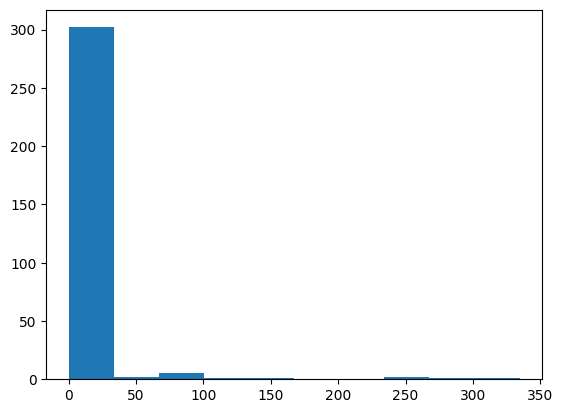

In [5]:
plt.hist(np.sum(adata_mer.X, 0), bins = 10);

In [4]:
def flip(a, xm):
        return(2*xm-a)

def get_hemi(S_mer, mesh):
    '''
    assume the axis of interest are both on the last axis. 
    '''
    xm = np.min(mesh.vertices[:,-1]) + np.ptp(mesh.vertices[:,-1])/2 # this is the center line to indicate the hemisphere 
    new_coords = S_mer.copy()
    new_coords[:,-1] = np.where(new_coords[:,-1] > xm, flip(new_coords[:,-1],xm), new_coords[:,-1])    
    return(new_coords)



In [5]:
S_mer = adata_mer.obsm['spatial']  # Spatial coordinates matrix, e.g., (2800 x 2)
S_mer = get_hemi(S_mer, mesh_LC)    
adata_mer.obsm['spatial'] = S_mer

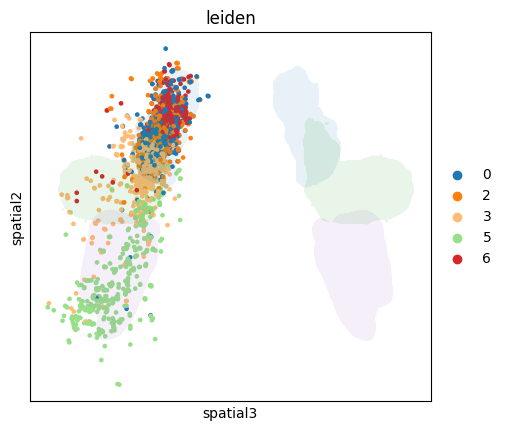

In [6]:
ax = sc.pl.embedding(adata_mer, basis = 'spatial', dimensions = (2,1), color = 'leiden', show = False)
ax.set_aspect('equal')
ax.invert_yaxis()
ax.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
ax.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
ax.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')

In [56]:
adata_mer.obsm['spatial'][:,1].max()

np.float64(291.0124127961281)

# cluster-specific distribution on D-V axis

In [7]:
groups = adata_mer.obs.groupby('leiden').groups


for group_id,cell_id in groups.items():
    adata_sub = adata_mer[cell_id]
    print(group_id, adata_sub.shape)

0 (720, 315)
2 (611, 315)
3 (554, 315)
5 (399, 315)
6 (367, 315)


/scratch/fast/48188/ipykernel_255720/223083224.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = adata_mer.obs.groupby('leiden').groups


In [8]:
import seaborn as sns
default_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
              '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
              '#bcbd22', '#17becf']

/scratch/fast/48188/ipykernel_255720/3017044612.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('tab20')


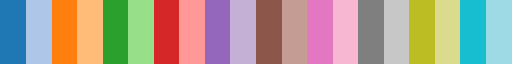

In [9]:
cm = plt.cm.get_cmap('tab20')
default_colors = list(cm.colors)
cm


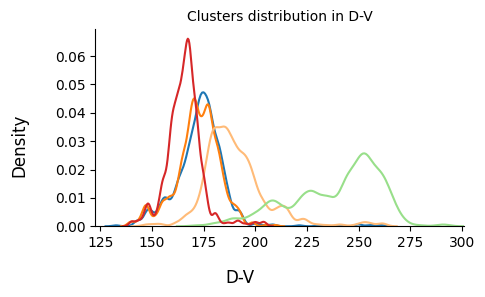

In [69]:

fig, axes = plt.subplots(nrows=1, ncols=1, sharex=True, sharey=True, figsize=(5,3))
ax = axes
for m, (group_id, cell_id) in enumerate(groups.items()):
    adata_sub = adata_mer[cell_id]
    DV_coords = adata_sub.obsm['spatial'][:, 1]
    sns.kdeplot(x=DV_coords, label='cells', bw_adjust=0.5,
                color=default_colors[int(group_id)], ax=ax)


    ax.set_xlim(adata_mer.obsm['spatial'][:, 1].min()-10,
                adata_mer.obsm['spatial'][:, 1].max()+10)
    ax.set_xlabel('');ax.set_ylabel('')
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
fig.text(0.5, 0.04, 'D-V', ha='center', fontsize=12)
fig.text(0.04, 0.5, 'Density', va='center', rotation='vertical', fontsize=12)
plt.title(f'Clusters distribution in D-V', fontsize=10)
plt.tight_layout(rect=[0.1, 0.1, 1, 1])
plt.show()


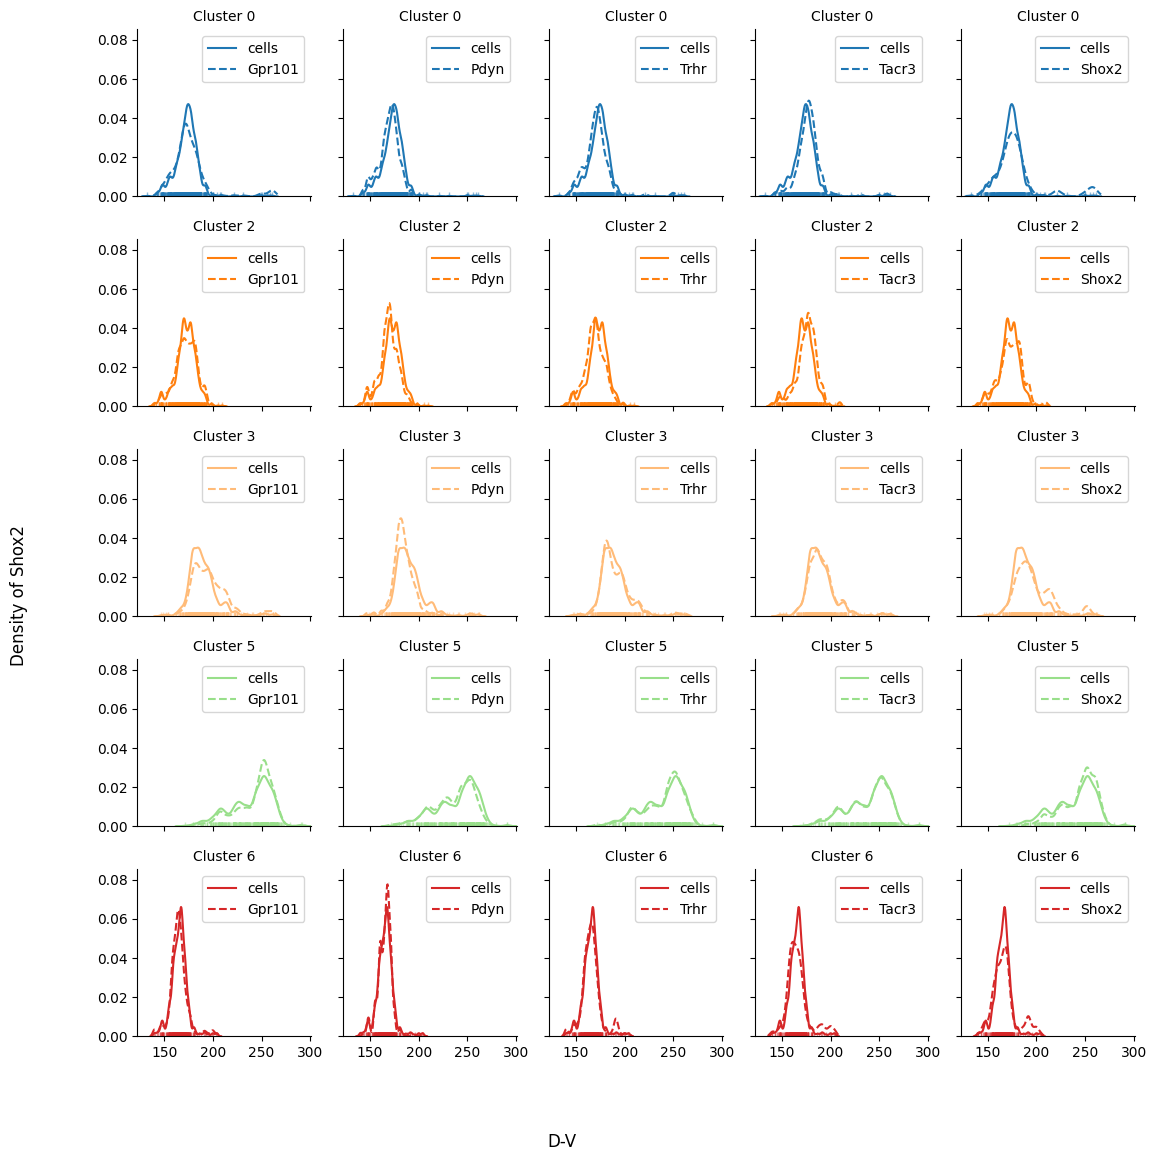

In [73]:
fig, axes = plt.subplots(nrows=5, ncols=len(intersted_genes), 
                         sharex=True, sharey=True, figsize=(12,12))
for g,gene_name in enumerate(intersted_genes):
    gene_idx = np.where(adata_sub.var_names == gene_name)[0][0]

    for m, (group_id, cell_id) in enumerate(groups.items()):
        adata_sub = adata_mer[cell_id]
        DV_coords = adata_sub.obsm['spatial'][:, 1]

        gene_expr = adata_sub.X[:, gene_idx]
        gene_expr = np.array(gene_expr).flatten()

        ax = axes[m, g]
        sns.kdeplot(x=DV_coords, label='cells', bw_adjust=0.5,
                    color=default_colors[int(group_id)], ax=ax)
        sns.kdeplot(x=DV_coords, weights=gene_expr, label=gene_name, bw_adjust=0.5,
                    color=default_colors[int(group_id)], linestyle="--", ax=ax)
        sns.rugplot(x=DV_coords, color=default_colors[int(group_id)], alpha=0.5, ax=ax)

        ax.set_title(f'Cluster {group_id}', fontsize=10)
        ax.set_xlim(adata_mer.obsm['spatial'][:, 1].min()-10,
                    adata_mer.obsm['spatial'][:, 1].max()+10)
        ax.legend()
        ax.set_xlabel('');ax.set_ylabel('')
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
fig.text(0.5, 0.04, 'D-V', ha='center', fontsize=12)
fig.text(0.04, 0.5, f'Density of genes', va='center', rotation='vertical', fontsize=12)
plt.tight_layout(rect=[0.1, 0.1, 1, 1])
plt.show()


In [106]:
xmin = adata_mer.obsm['spatial'][:,1].min() - 10
xmax = adata_mer.obsm['spatial'][:,1].max() + 10
bins = np.linspace(xmin, xmax, 21)
gene_expr = adata_sub.X[:, gene_idx]
gene_expr = np.array(gene_expr).flatten()

cell_counts, _ = np.histogram(DV_coords, bins=bins)
weighted_counts, _ = np.histogram(DV_coords, bins=bins, weights=gene_expr)
norm_hist = weighted_counts / (cell_counts + 1e-20)  # add epsilon to avoid division by zero
bin_centers = 0.5 * (bins[:-1] + bins[1:])

In [107]:
kde_cell = gaussian_kde(DV_coords, bw_method=bw_method_params)
density_cell = kde_cell(grid)

kde_expr = gaussian_kde(DV_coords, weights=gene_expr, bw_method=bw_method_params)
density_expr = kde_expr(grid)
normalized_expr = density_expr / (density_cell + 1e-10)  # epsilon avoids division by zero

<BarContainer object of 20 artists>

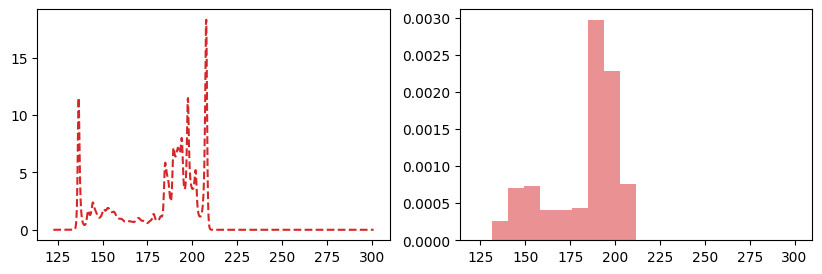

In [108]:
plt.figure(figsize = (10,3))
plt.subplot(1,2,1);plt.plot(grid,density_expr/(density_cell+1e-6),'--', color=default_colors[int(group_id)], 
            label = 'normalized counts')
plt.subplot(1,2,2);plt.bar(bin_centers, norm_hist, width=(bins[1]-bins[0]),
        alpha=0.5, color=default_colors[int(group_id)], label='Normalized Gpr101 Histogram')


/scratch/fast/48188/ipykernel_255720/787468192.py:32: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts


(122.58497735975959, 301.0124127961281)

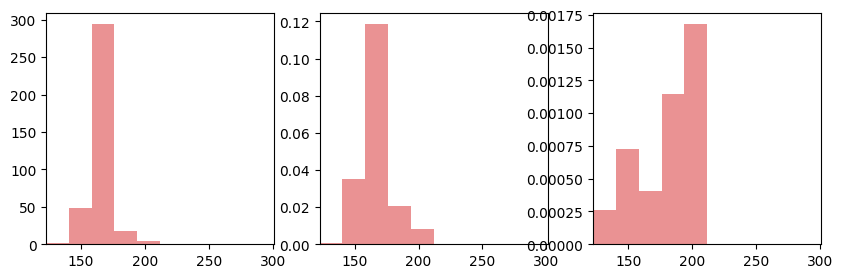

In [305]:
num_bins = 10

fig, axes = plt.subplots(1,3, figsize = (10,3))
adata_sub = adata_mer[cell_id]
DV_coords = adata_sub.obsm['spatial'][:,1]    
gene_expr = adata_sub.X[:, gene_idx]
gene_expr = np.array(gene_expr).flatten()

# compute KDE
kde_cell = gaussian_kde(DV_coords, bw_method=bw_method_params)
density_cell = kde_cell(grid)
kde_expr = gaussian_kde(DV_coords, weights=gene_expr, bw_method=bw_method_params)
density_expr = kde_expr(grid)

bins = np.linspace(xmin, xmax, num_bins+1)
cell_counts, _ = np.histogram(DV_coords, bins=bins)
weighted_counts, _ = np.histogram(DV_coords, bins=bins, weights=gene_expr)        
bin_centers = 0.5 * (bins[:-1] + bins[1:])

ax = axes[0]
ax.bar(bin_centers, cell_counts, width=(bins[1]-bins[0]),
    alpha=0.5, color=default_colors[int(group_id)], label=f'Normalized {gene_name} Histogram')
ax.set_xlim(xmin, xmax)

ax = axes[1]
ax.bar(bin_centers, weighted_counts, width=(bins[1]-bins[0]),
    alpha=0.5, color=default_colors[int(group_id)], label=f'Normalized {gene_name} Histogram')
ax.set_xlim(xmin, xmax)

ax = axes[2]
mean_density = weighted_counts/cell_counts
ax.bar(bin_centers, mean_density, width=(bins[1]-bins[0]),
    alpha=0.5, color=default_colors[int(group_id)], label=f'Normalized {gene_name} Histogram')
ax.set_xlim(xmin, xmax)

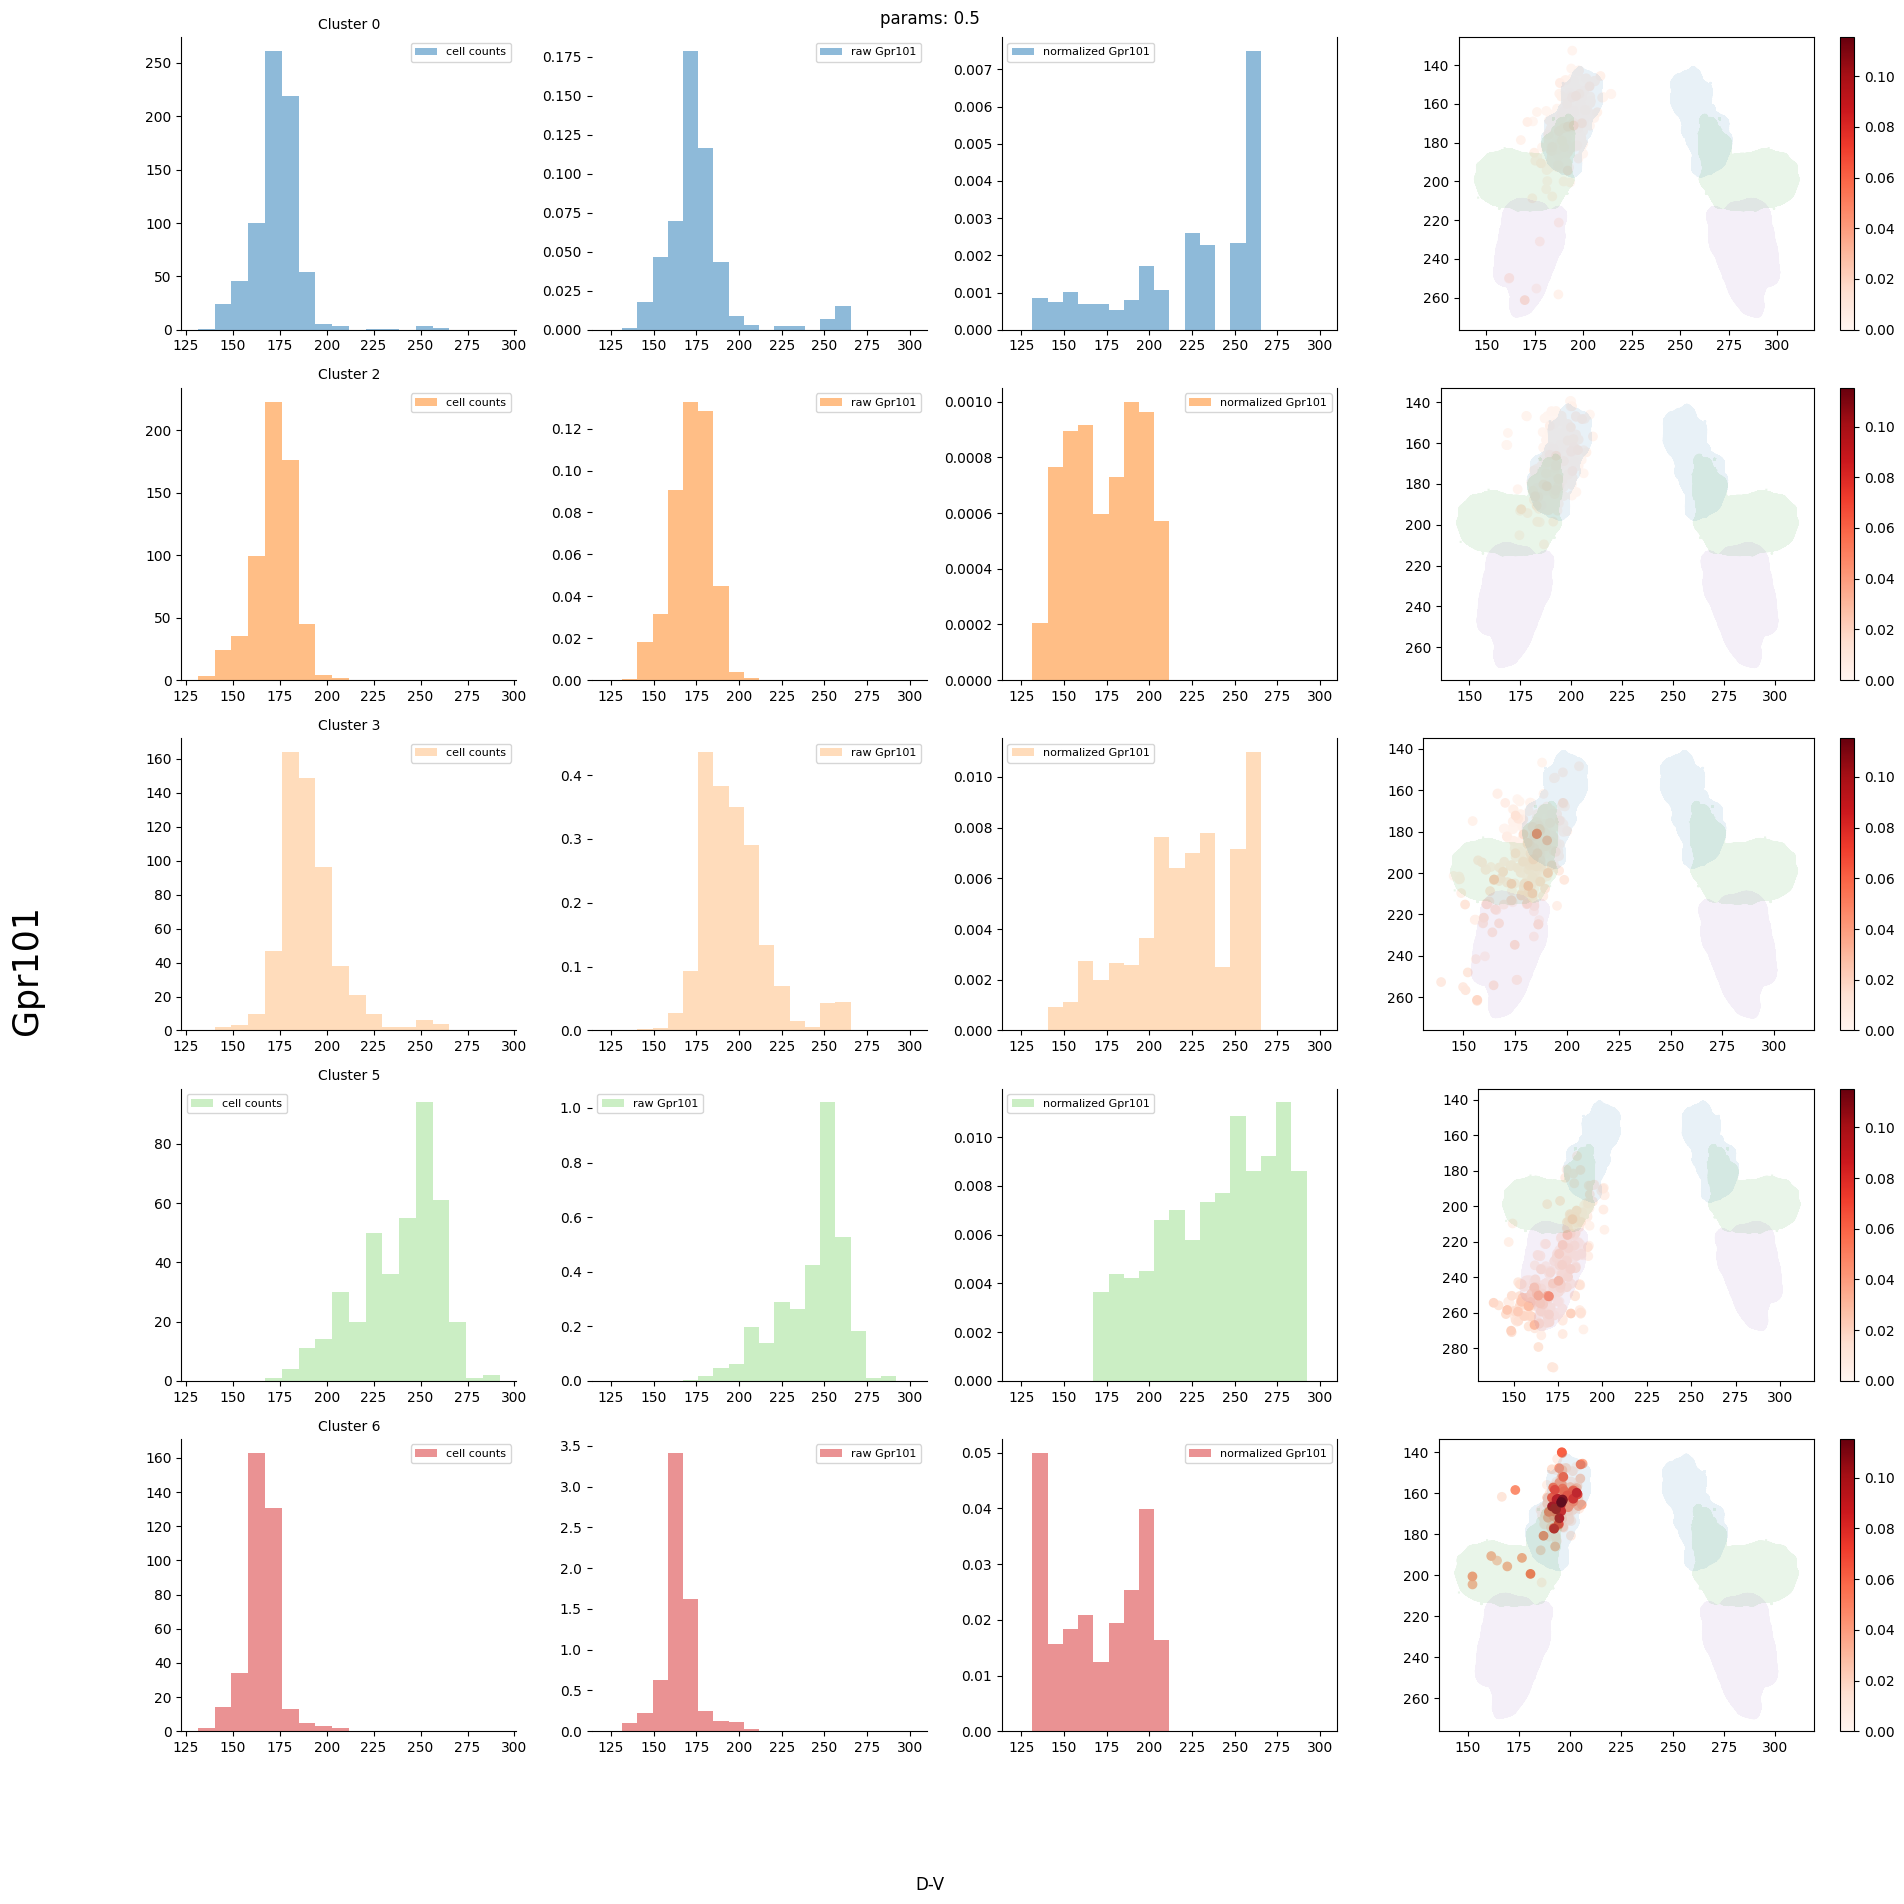

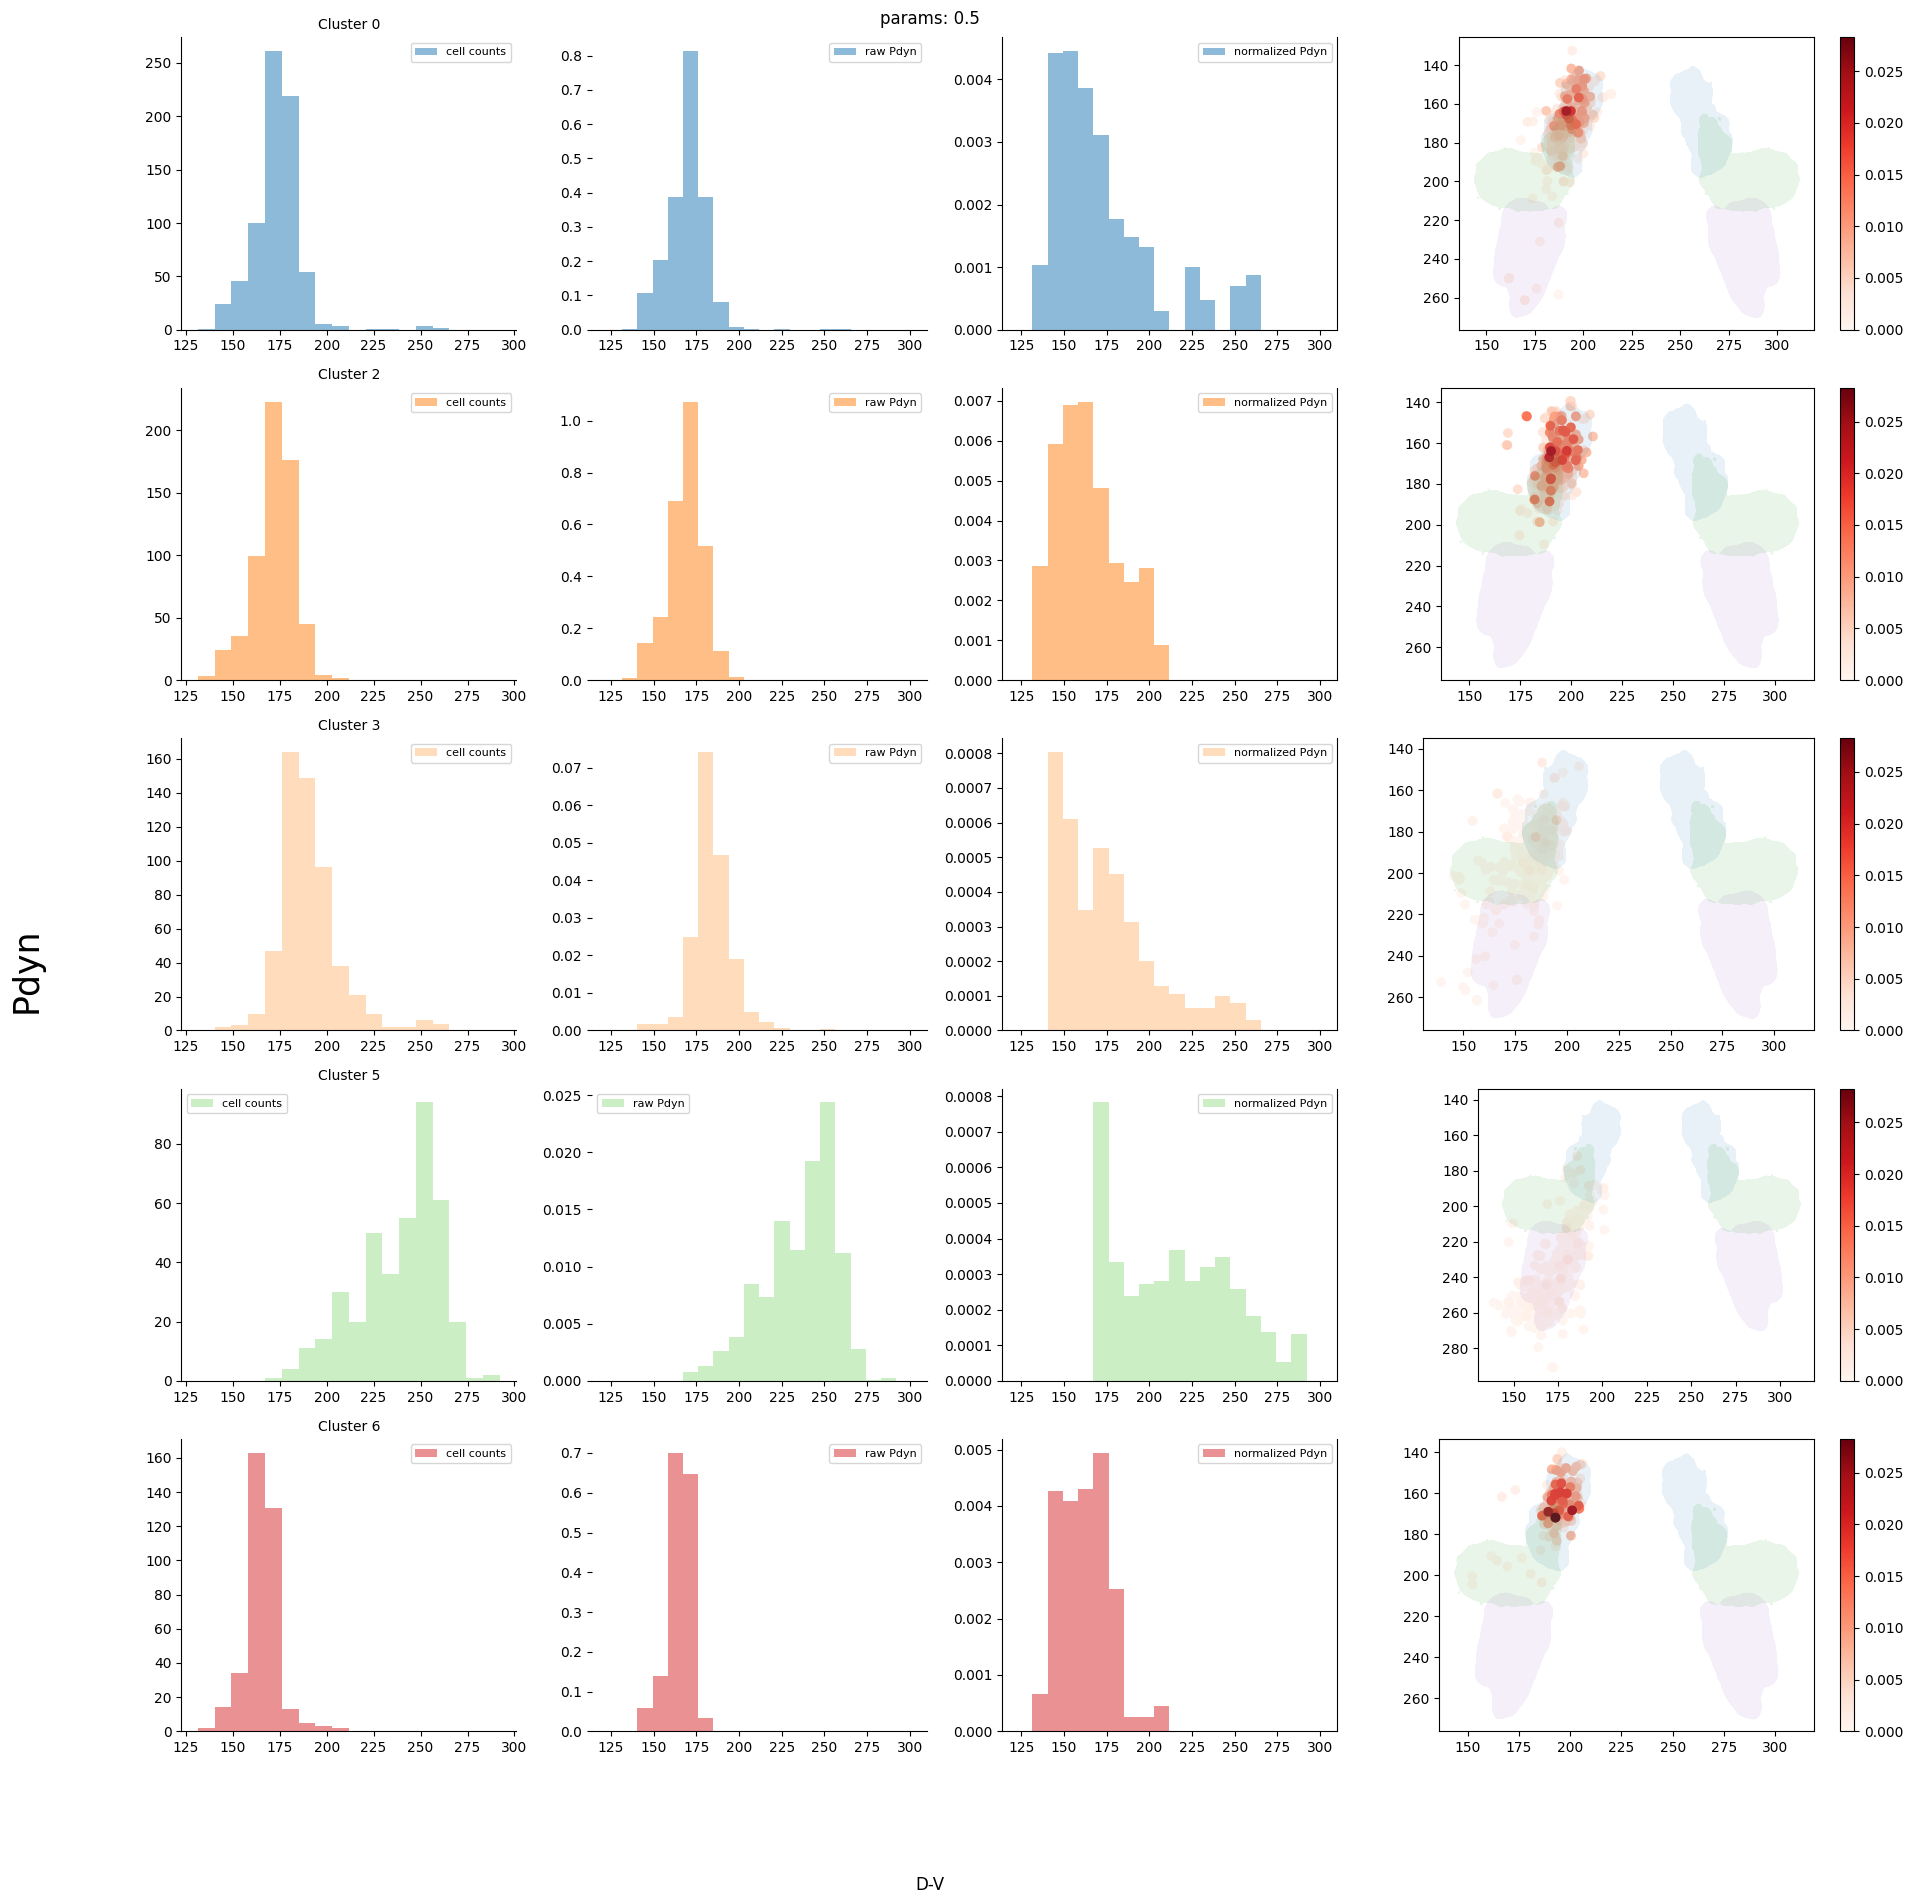

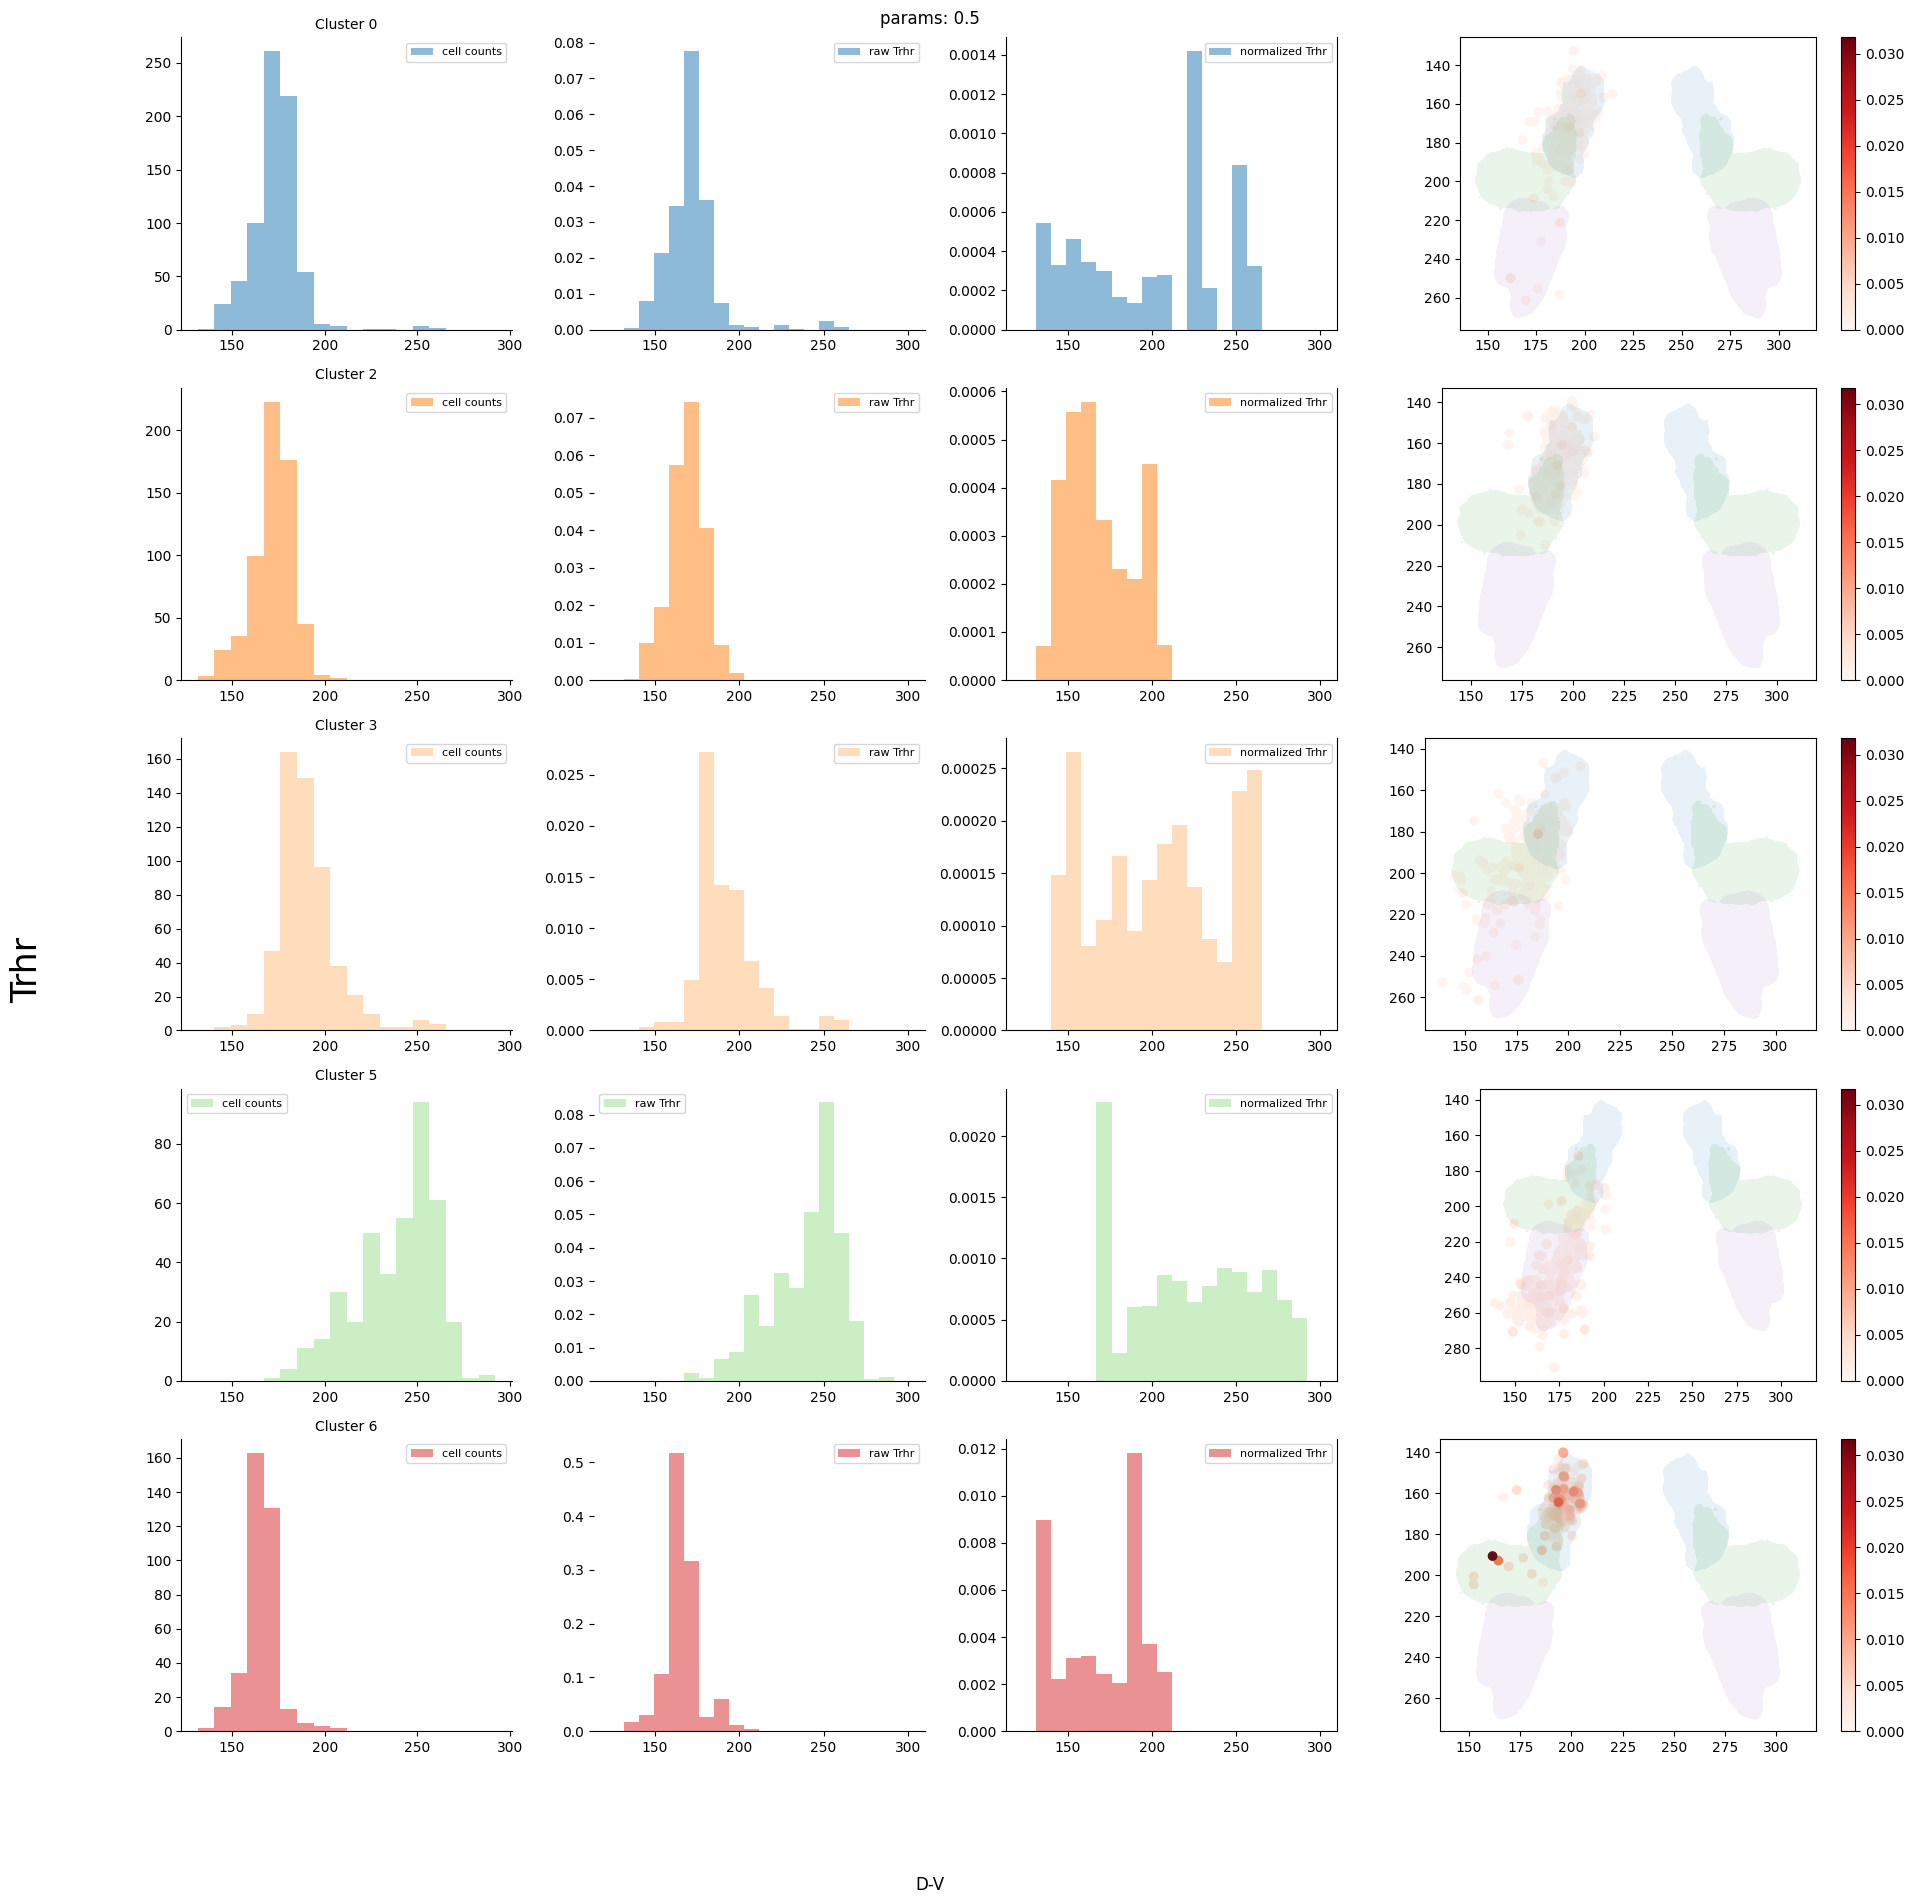

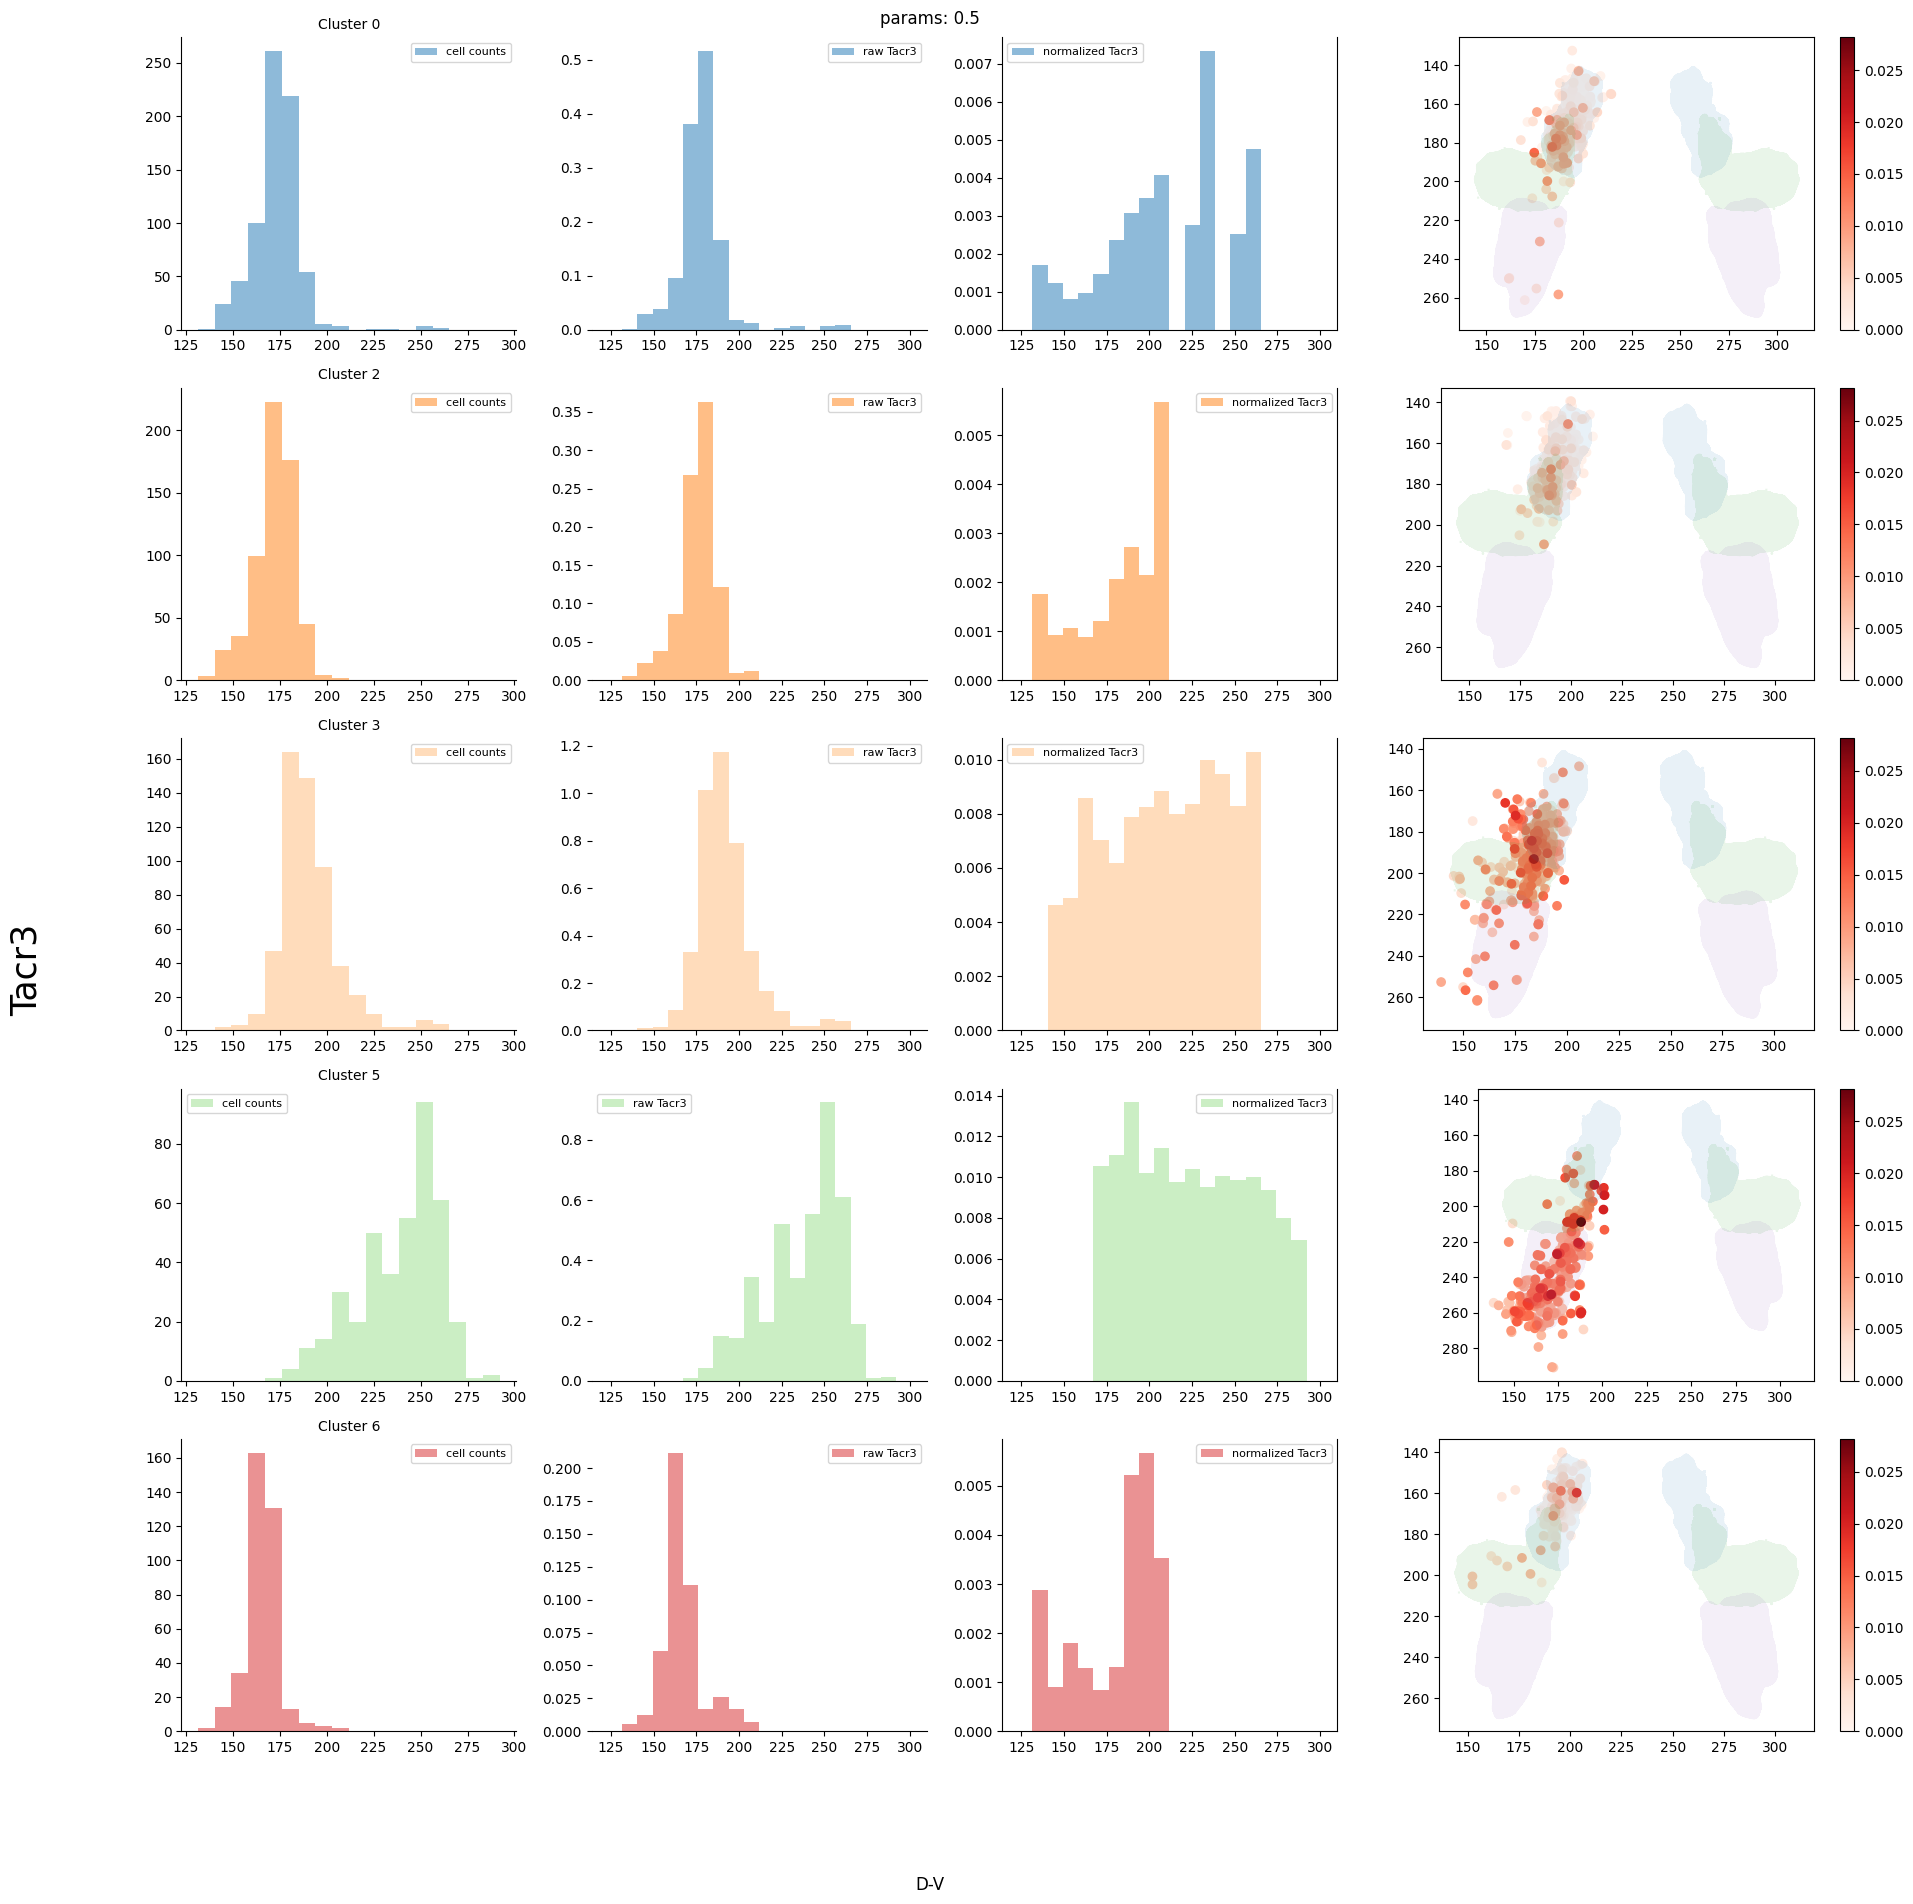

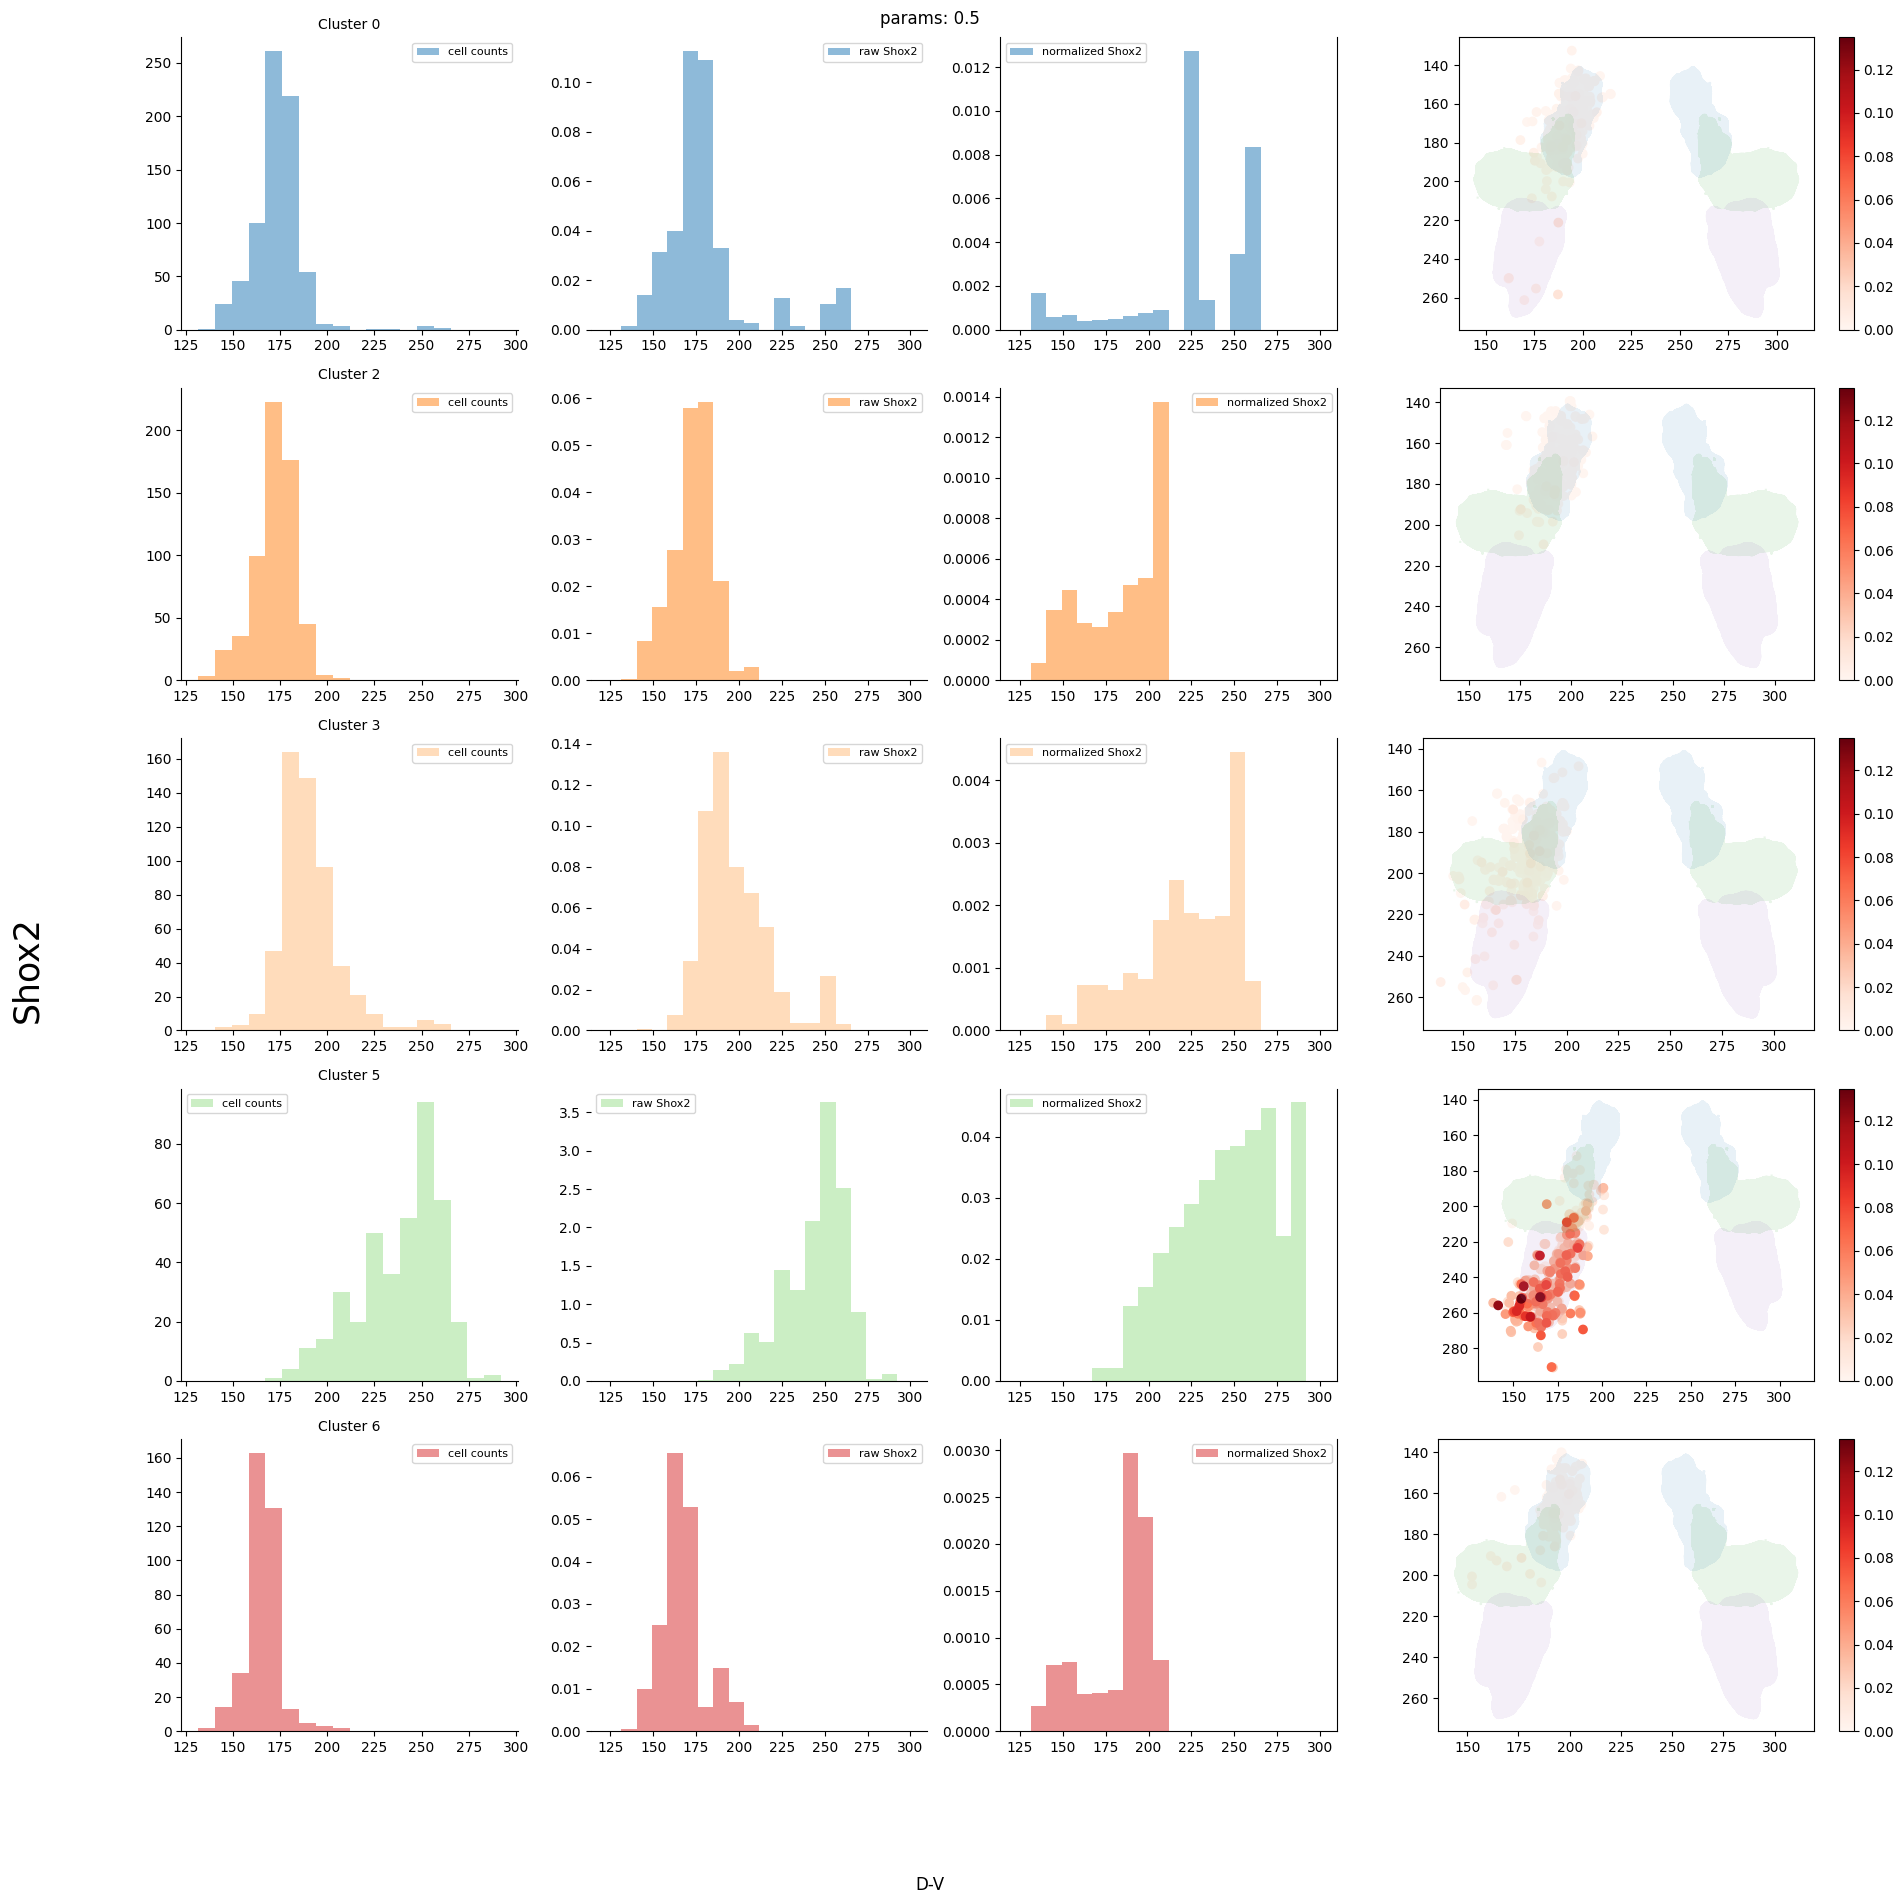

In [317]:
num_bins = 20
xmin = adata_mer.obsm['spatial'][:,1].min() - 10
xmax = adata_mer.obsm['spatial'][:,1].max() + 10
bins = np.linspace(xmin, xmax, num_bins+1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

bw_method_params = 0.5
from scipy.stats import gaussian_kde

for g,gene_name in enumerate(intersted_genes):
    gene_idx = np.where(adata_sub.var_names == gene_name)[0][0]    
    max_exp = np.array(adata_mer[:,gene_name].X)[:,0].max()
    fig, axes = plt.subplots(nrows=5, ncols=4, sharex=False, sharey=False, 
                             figsize=(20,20),gridspec_kw={'width_ratios': [1, 1, 1, 1.5]})
    for m, (group_id, cell_id) in enumerate(groups.items()):
        adata_sub = adata_mer[cell_id]
        DV_coords = adata_sub.obsm['spatial'][:,1]    
        gene_expr = adata_sub.X[:, gene_idx]
        gene_expr = np.array(gene_expr).flatten()

        
        cell_counts, _ = np.histogram(DV_coords, bins=bins)
        weighted_counts, _ = np.histogram(DV_coords, bins=bins, weights=gene_expr)        
        normalized_expr = weighted_counts / (cell_counts + 1e-10)  # epsilon avoids division by zero
        
        axes[m,1].get_shared_x_axes().joined(axes[m,0], axes[m,1])
        axes[m,2].get_shared_x_axes().joined(axes[m,0], axes[m,2])
        
        ax = axes[m, 0]        
        ax.bar(bin_centers, cell_counts, width=(bins[1]-bins[0]),
               alpha=0.5, color=default_colors[int(group_id)], label=f'cell counts')
        ax.set_title(f'Cluster {group_id}', fontsize=10)
        ax.set_xlim(xmin, xmax)
        ax.legend(fontsize=8)
        ax.set_xlabel('');ax.set_ylabel('')    
        ax.spines["top"].set_visible(False);
        ax.spines["right"].set_visible(False)

        ax = axes[m, 1]
        ax.bar(bin_centers, weighted_counts, width=(bins[1]-bins[0]),
               alpha=0.5, color=default_colors[int(group_id)], label=f'raw {gene_name}')
#         ax.set_xlim(xmin, xmax)
        ax.legend(fontsize=8)
        ax.set_xlabel('');ax.set_ylabel('')    
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False),; ax.spines["left"].set_visible(False)

        ax = axes[m, 2]
        ax.bar(bin_centers, normalized_expr, width=(bins[1]-bins[0]),
            alpha=0.5, color=default_colors[int(group_id)], label=f'normalized {gene_name}')
#         ax.set_xlim(xmin, xmax)
        ax.legend(fontsize=8)
        ax.set_xlabel('');ax.set_ylabel('')    
        ax.spines["top"].set_visible(False); ax.spines
        
        ax = axes[m, 3]
        allexpressionvalues = np.array(adata_sub[:,gene_name].X)[:,0]
        cellorders = np.argsort(allexpressionvalues)
        scat = ax.scatter(adata_sub.obsm['spatial'][cellorders,2],adata_sub.obsm['spatial'][cellorders,1],cmap ='Reds',
                             c=allexpressionvalues[cellorders], vmax = max_exp,vmin = 0)    
        plt.colorbar(scat)
        ax.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
        ax.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
        ax.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
        ax.invert_yaxis()
        ax.set_aspect('equal')
        ax.set_xlabel('');ax.set_ylabel('')    


    fig.text(0.5, 0.04, 'D-V', ha='center', fontsize=12)
    fig.text(0.04, 0.5, f'{gene_name}', va='center', rotation='vertical', fontsize=25)
    fig.suptitle(f'params: {bw_method_params}')
    fig.tight_layout()
    plt.tight_layout(rect=[0.1, 0.1, 1, 1])
    plt.show()


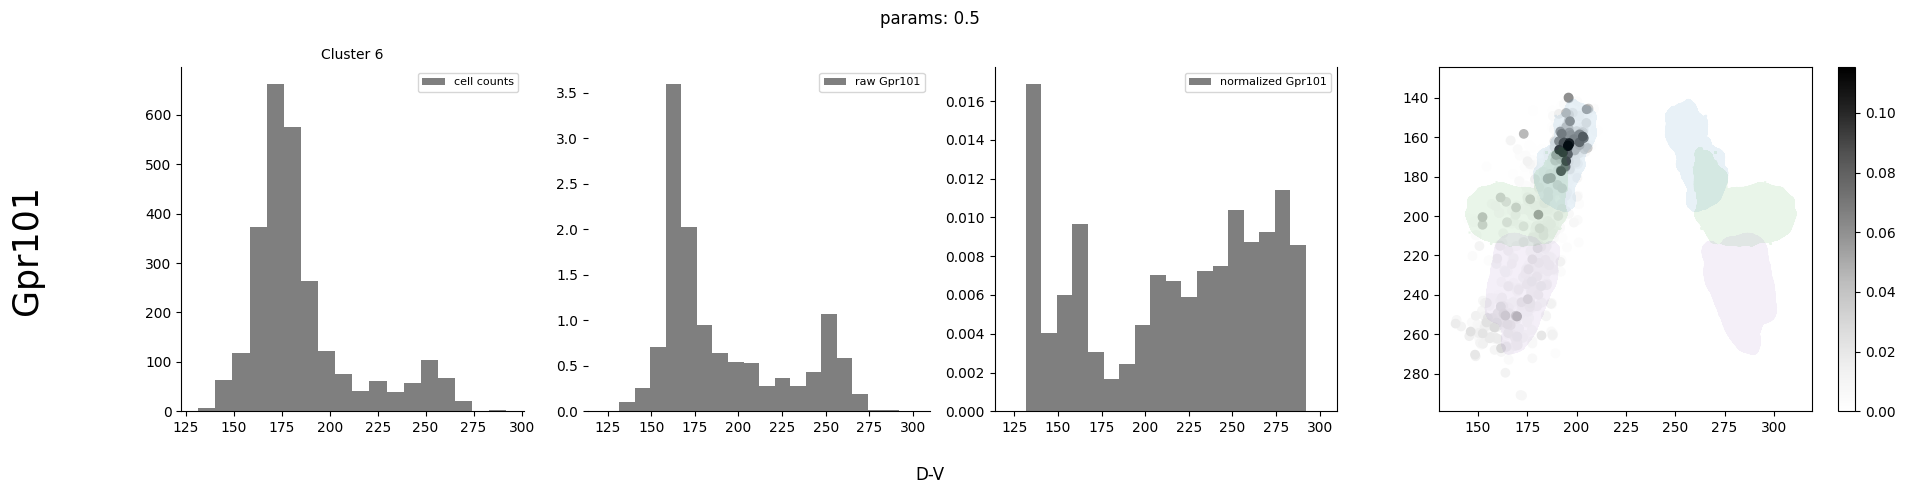

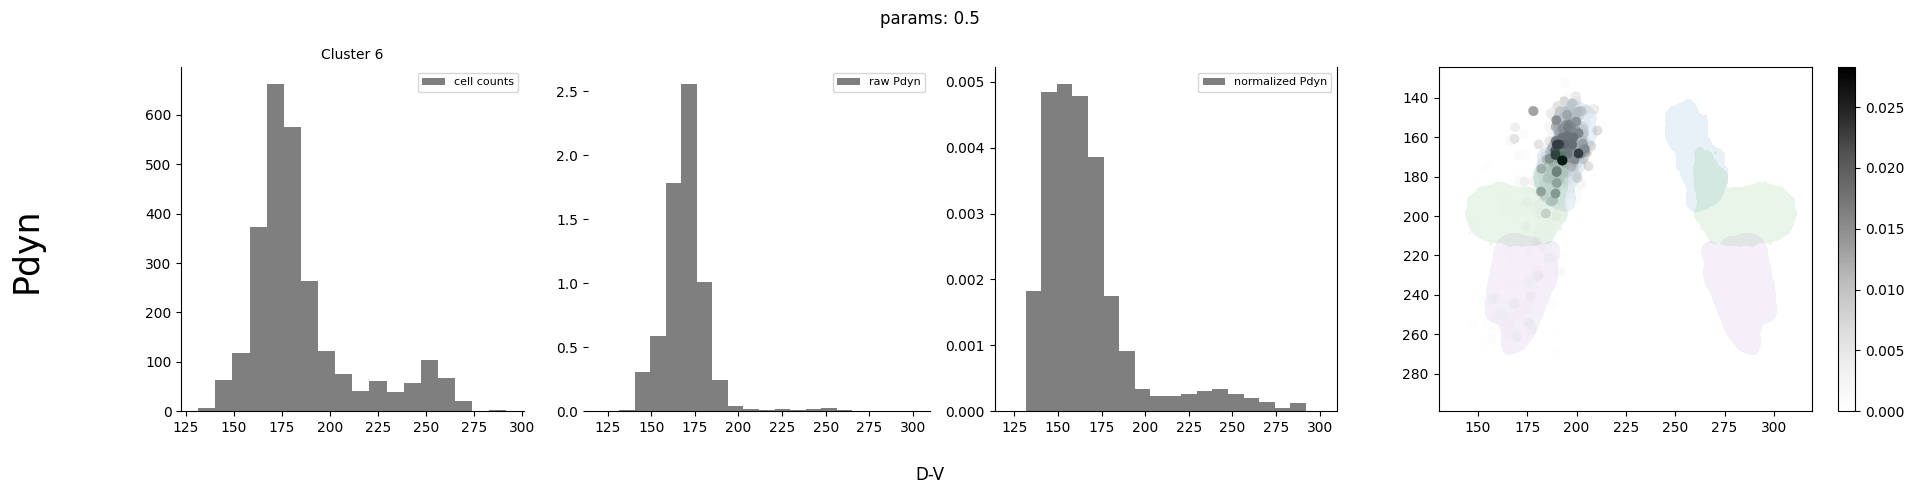

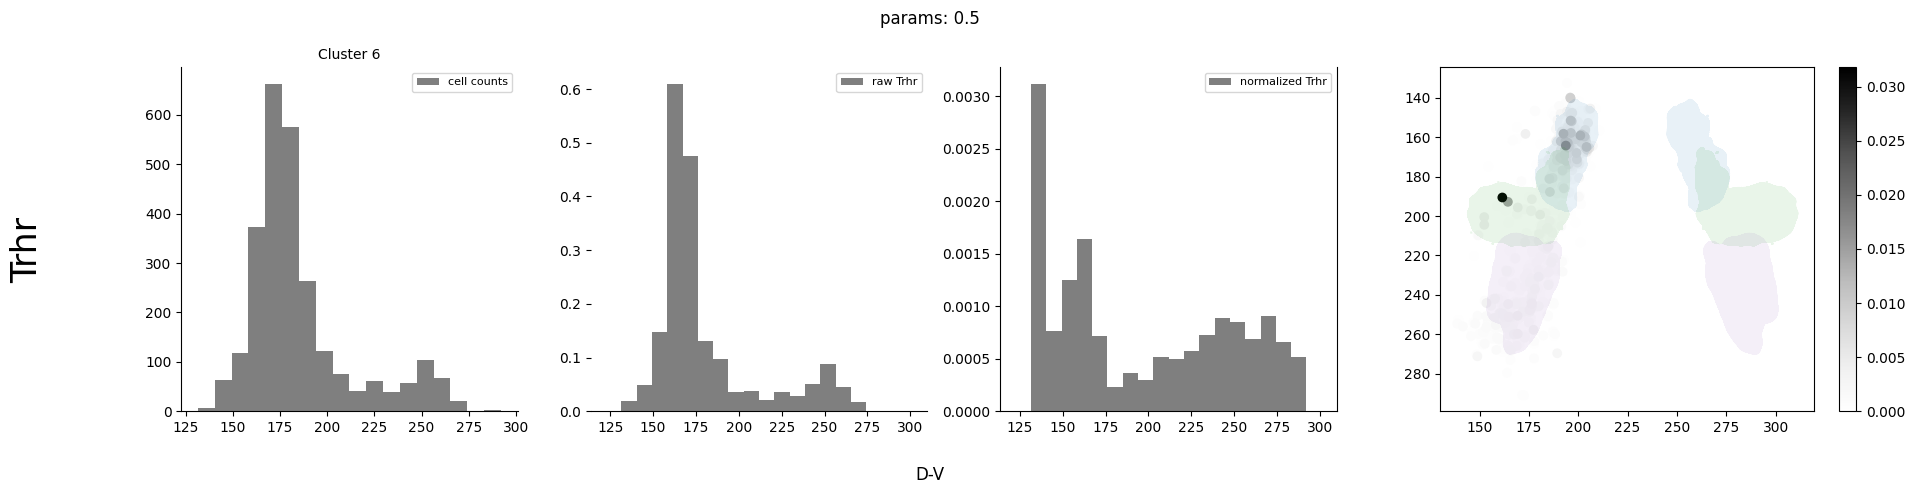

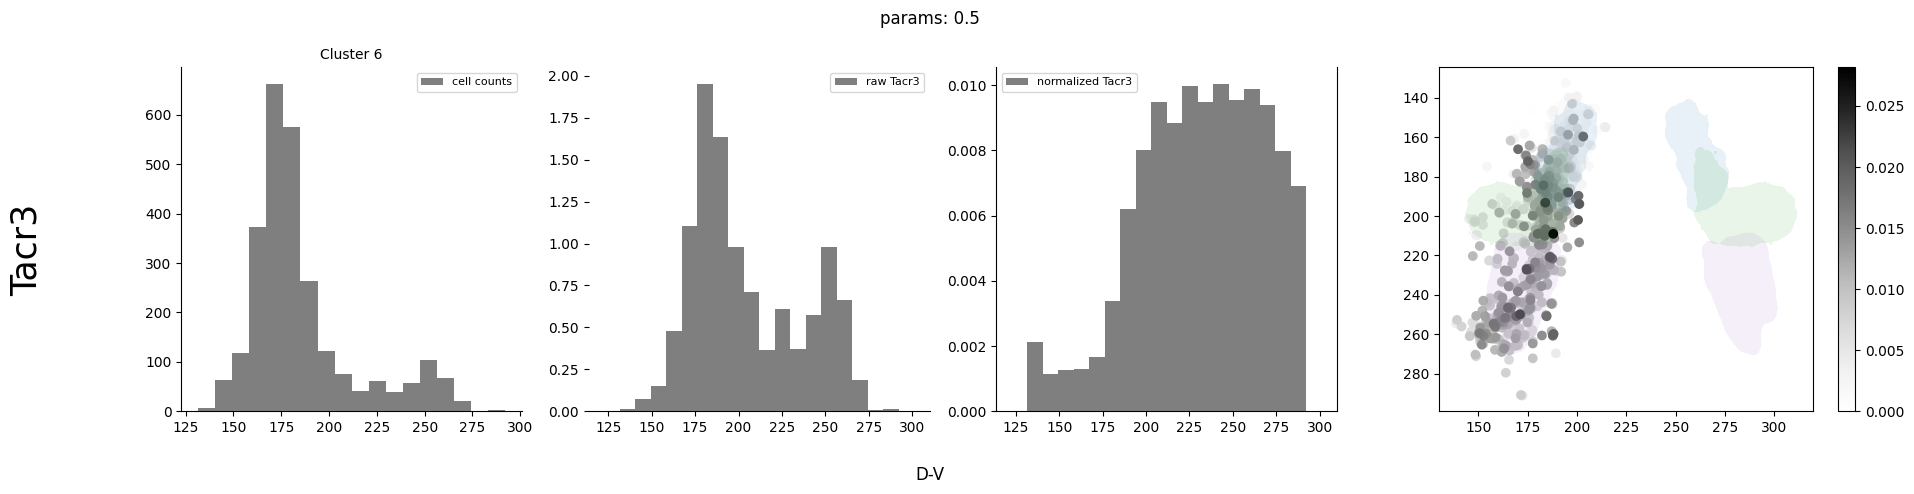

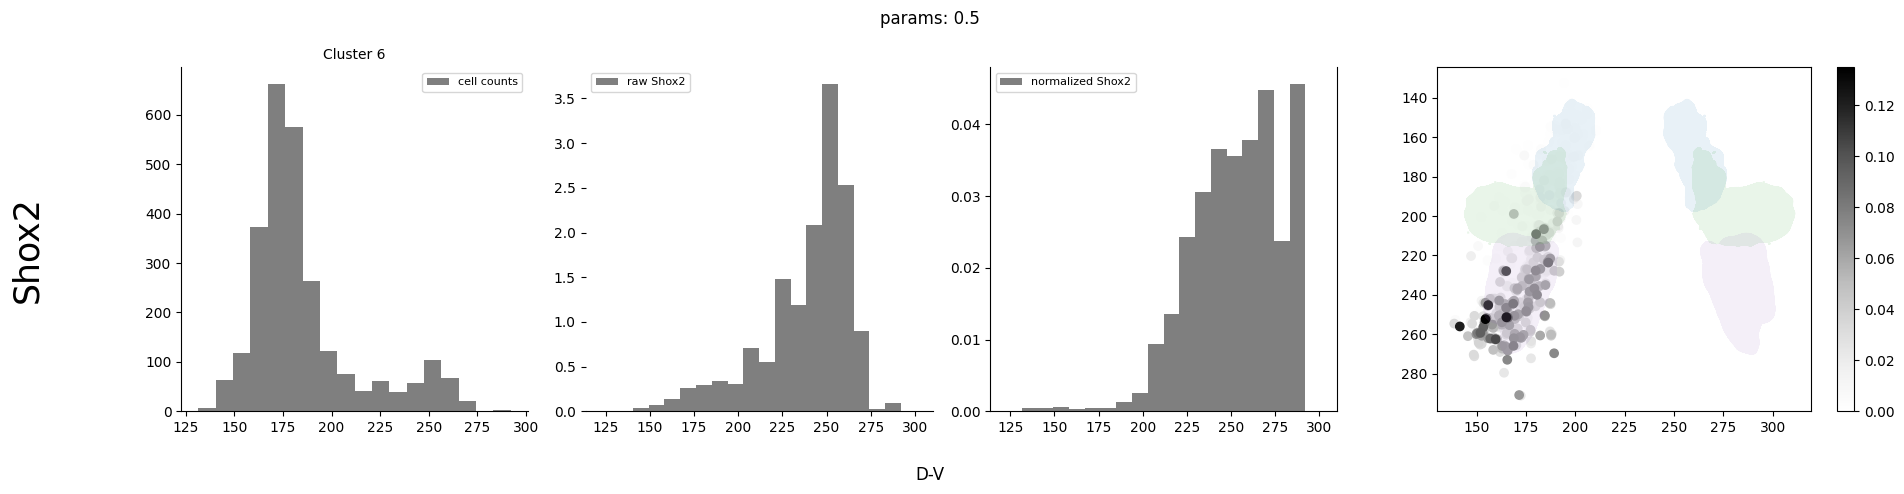

In [322]:
num_bins = 20
xmin = adata_mer.obsm['spatial'][:,1].min() - 10
xmax = adata_mer.obsm['spatial'][:,1].max() + 10
bins = np.linspace(xmin, xmax, num_bins+1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

bw_method_params = 0.5
from scipy.stats import gaussian_kde

for g,gene_name in enumerate(intersted_genes):
    gene_idx = np.where(adata_mer.var_names == gene_name)[0][0]    
    max_exp = np.array(adata_mer[:,gene_name].X)[:,0].max()
    fig, axes = plt.subplots(nrows=1, ncols=4, sharex=False, sharey=False, 
                             figsize=(20,5),gridspec_kw={'width_ratios': [1, 1, 1, 1.5]})

    adata_sub = adata_mer.copy()
    DV_coords = adata_sub.obsm['spatial'][:,1]    
    gene_expr = adata_sub.X[:, gene_idx]
    gene_expr = np.array(gene_expr).flatten()


    cell_counts, _ = np.histogram(DV_coords, bins=bins)
    weighted_counts, _ = np.histogram(DV_coords, bins=bins, weights=gene_expr)        
    normalized_expr = weighted_counts / (cell_counts + 1e-10)  # epsilon avoids division by zero

    ax = axes[0]        
    ax.bar(bin_centers, cell_counts, width=(bins[1]-bins[0]),
           alpha=0.5, color='k', label=f'cell counts')
    ax.set_xlim(xmin, xmax)
    ax.legend(fontsize=8)
    ax.set_xlabel('');ax.set_ylabel('')    
    ax.spines["top"].set_visible(False);
    ax.spines["right"].set_visible(False)

    ax = axes[1]
    ax.bar(bin_centers, weighted_counts, width=(bins[1]-bins[0]),
           alpha=0.5, color='k', label=f'raw {gene_name}')
#         ax.set_xlim(xmin, xmax)
    ax.legend(fontsize=8)
    ax.set_xlabel('');ax.set_ylabel('')    
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False),; ax.spines["left"].set_visible(False)

    ax = axes[2]
    ax.bar(bin_centers, normalized_expr, width=(bins[1]-bins[0]),
        alpha=0.5,color='k', label=f'normalized {gene_name}')
#         ax.set_xlim(xmin, xmax)
    ax.legend(fontsize=8)
    ax.set_xlabel('');ax.set_ylabel('')    
    ax.spines["top"].set_visible(False); ax.spines

    ax = axes[3]
    allexpressionvalues = np.array(adata_sub[:,gene_name].X)[:,0]
    cellorders = np.argsort(allexpressionvalues)
    scat = ax.scatter(adata_sub.obsm['spatial'][cellorders,2],adata_sub.obsm['spatial'][cellorders,1],cmap ='Grays',
                         c=allexpressionvalues[cellorders], vmax = max_exp,vmin = 0)    
    plt.colorbar(scat)
    ax.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    ax.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    ax.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.set_xlabel('');ax.set_ylabel('')    


    fig.text(0.5, 0.04, 'D-V', ha='center', fontsize=12)
    fig.text(0.04, 0.5, f'{gene_name}', va='center', rotation='vertical', fontsize=25)
    fig.suptitle(f'params: {bw_method_params}')
    fig.tight_layout()
    plt.tight_layout(rect=[0.1, 0.1, 1, 1])
    plt.show()


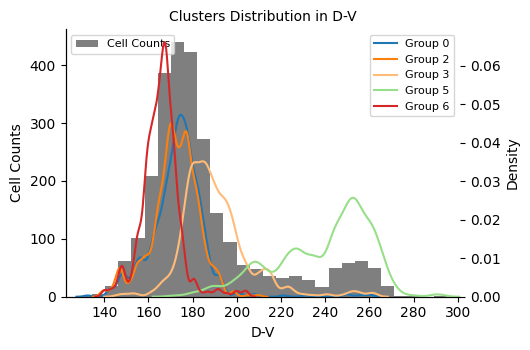

In [330]:

DV_all = adata_mer.obsm['spatial'][:, 1]
xmin = DV_all.min() - 10
xmax = DV_all.max() + 10

bins = np.linspace(xmin, xmax, 31)
cell_counts_all, _ = np.histogram(DV_all, bins=bins)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

fig, ax1 = plt.subplots(figsize=(6, 4))
ax2 = ax1.twinx()
ax1.bar(bin_centers, cell_counts_all, width=(bins[1]-bins[0]),
        alpha=0.5, color='k', label='Cell Counts')
for m, (group_id, cell_id) in enumerate(groups.items()):
    adata_sub = adata_mer[cell_id]
    DV_coords = adata_sub.obsm['spatial'][:, 1]
    sns.kdeplot(x=DV_coords, label=f'Group {group_id}', bw_adjust=0.5,
                color=default_colors[int(group_id)], ax=ax2)

ax1.set_xlim(xmin, xmax)
ax1.set_xlabel('D-V')
ax1.set_ylabel('Cell Counts')
ax2.set_ylabel('Density')

for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)
    ax2.spines[spine].set_visible(False)
ax1.legend(fontsize=8, loc='upper left')
ax2.legend(fontsize=8, loc='upper right')

plt.title('Clusters Distribution in D-V', fontsize=10)
plt.tight_layout(rect=[0.1, 0.1, 1, 1])
plt.show()

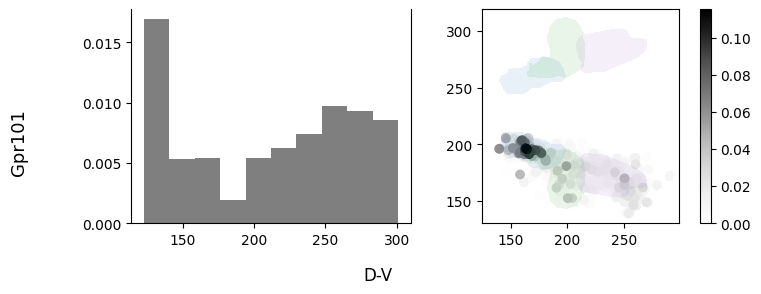

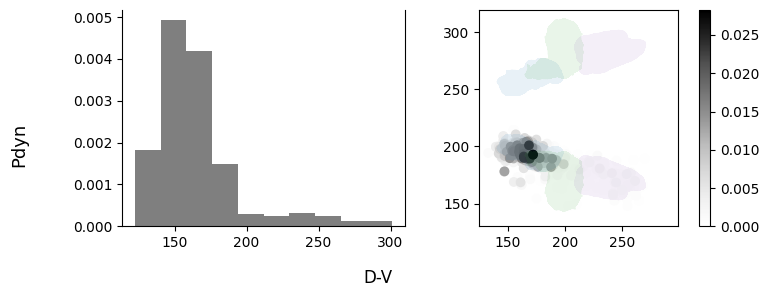

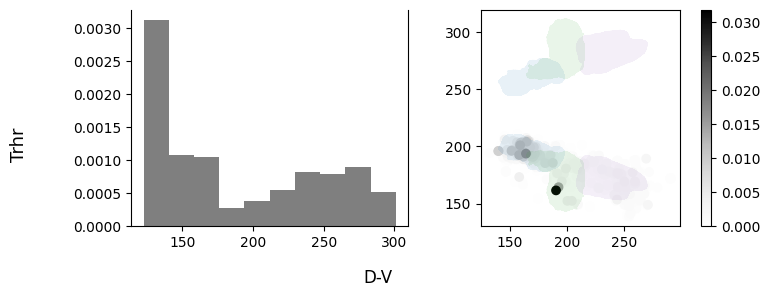

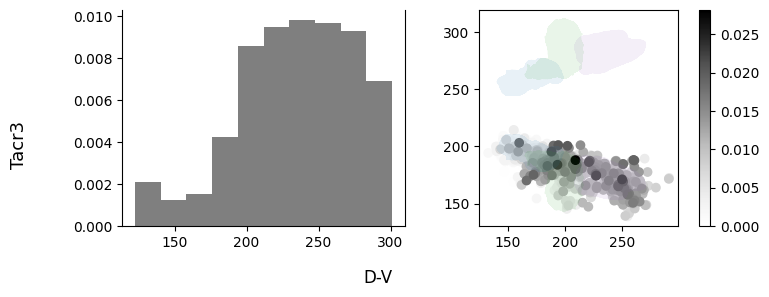

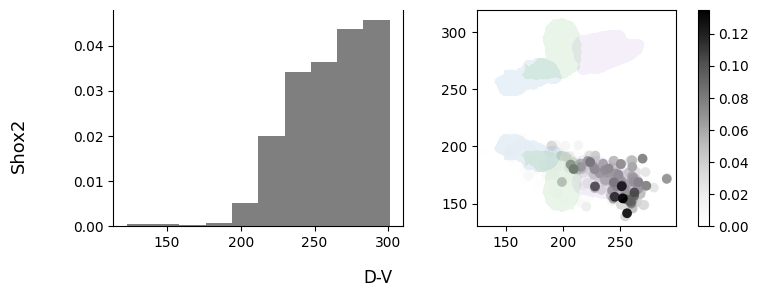

In [346]:
num_bins = 10
xmin = adata_mer.obsm['spatial'][:,1].min() - 10
xmax = adata_mer.obsm['spatial'][:,1].max() + 10
bins = np.linspace(xmin, xmax, num_bins+1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

bw_method_params = 0.5
from scipy.stats import gaussian_kde

for g,gene_name in enumerate(intersted_genes):
    gene_idx = np.where(adata_mer.var_names == gene_name)[0][0]    
    max_exp = np.array(adata_mer[:,gene_name].X)[:,0].max()
    fig, axes = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=False, 
                             figsize=(8,3),gridspec_kw={'width_ratios': [1,1.5]})

    adata_sub = adata_mer.copy()
    DV_coords = adata_sub.obsm['spatial'][:,1]    
    gene_expr = adata_sub.X[:, gene_idx]
    gene_expr = np.array(gene_expr).flatten()

    cell_counts, _ = np.histogram(DV_coords, bins=bins)
    cell_counts_all, _ = np.histogram(DV_all, bins=bins)
    weighted_counts, _ = np.histogram(DV_coords, bins=bins, weights=gene_expr)        
    normalized_expr = weighted_counts / (cell_counts + 1e-10)  # epsilon avoids division by zero

    ax = axes[0]        
    ax.bar(bin_centers, normalized_expr, width=(bins[1]-bins[0]),
        alpha=0.5,color='k', label=f'normalized {gene_name}')
    ax.set_xlabel('');ax.set_ylabel('')    
    ax.spines["top"].set_visible(False); ax.spines

    ax = axes[1]
    allexpressionvalues = np.array(adata_sub[:,gene_name].X)[:,0]
    cellorders = np.argsort(allexpressionvalues)
    scat = ax.scatter(adata_sub.obsm['spatial'][cellorders,1],adata_sub.obsm['spatial'][cellorders,2],cmap ='Grays',
                         c=allexpressionvalues[cellorders], vmax = max_exp,vmin = 0)    
    plt.colorbar(scat)
    ax.triplot(mesh_LC.vertices.T[1], mesh_LC.vertices.T[2], mesh_LC.faces, alpha = .1, label = 'LC')
    ax.triplot(mesh_CD.vertices.T[1], mesh_CD.vertices.T[2], mesh_CD.faces, alpha = .1, label = 'CD')
    ax.triplot(mesh_CV.vertices.T[1], mesh_CV.vertices.T[2], mesh_CV.faces, alpha = .1, label = 'CV')
#     ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.set_xlabel('');ax.set_ylabel('')    


    fig.text(0.5, 0.04, 'D-V', ha='center', fontsize=12)
    fig.text(0.04, 0.5, f'{gene_name}', va='center', rotation='vertical', fontsize=13)
    fig.tight_layout()
    plt.tight_layout(rect=[0.1, 0.1, 1, 1])
    plt.show()


In [349]:
import seaborn as sns
import matplotlib.gridspec as gridspec

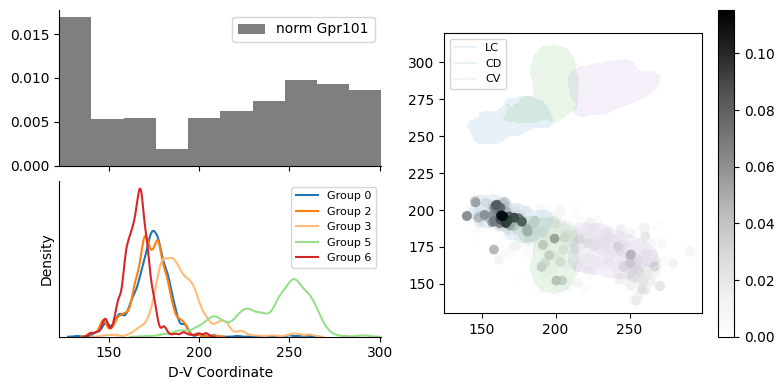

<Figure size 640x480 with 0 Axes>

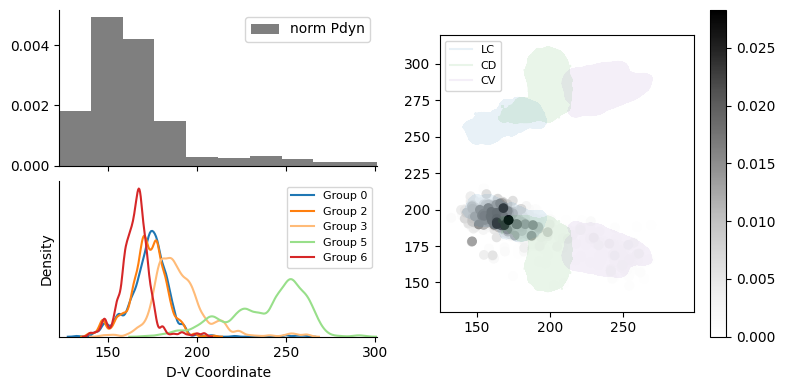

<Figure size 640x480 with 0 Axes>

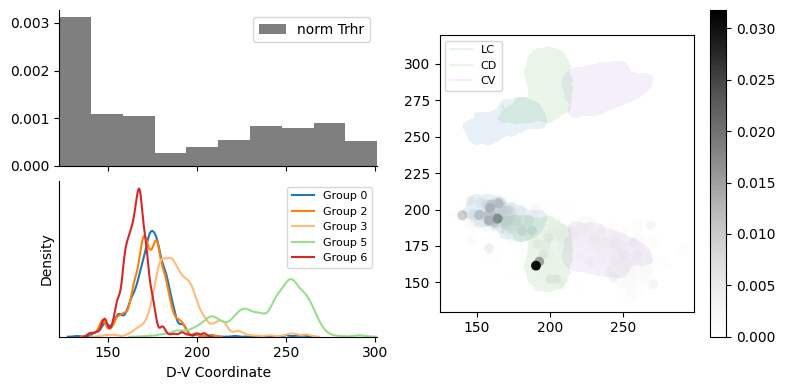

<Figure size 640x480 with 0 Axes>

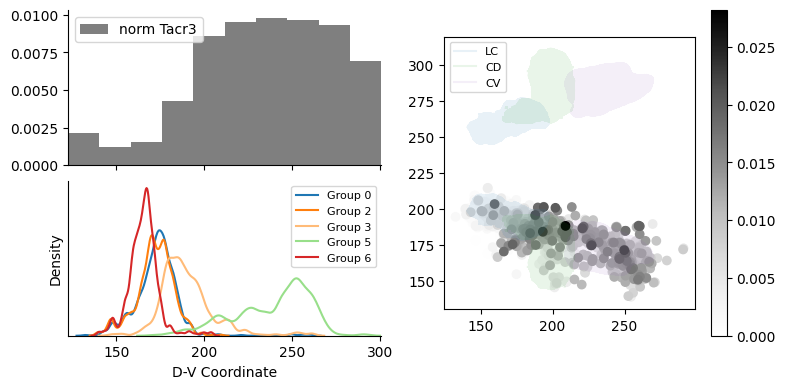

<Figure size 640x480 with 0 Axes>

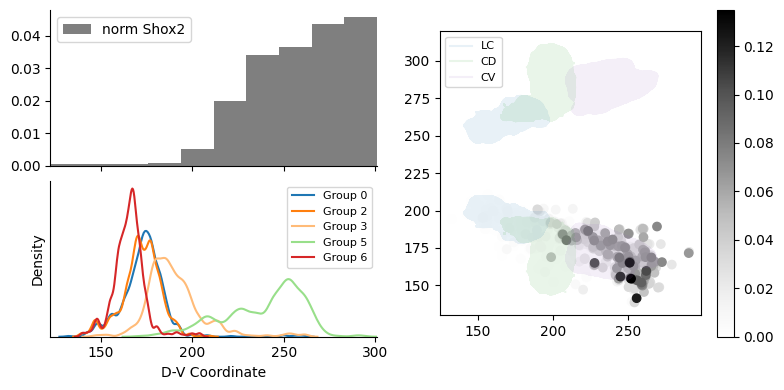

<Figure size 640x480 with 0 Axes>

In [374]:
num_bins = 10
xmin = adata_mer.obsm['spatial'][:,1].min() - 10
xmax = adata_mer.obsm['spatial'][:,1].max() + 10
bins = np.linspace(xmin, xmax, num_bins+1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

bw_method_params = 0.5
from scipy.stats import gaussian_kde

for g,gene_name in enumerate(intersted_genes):
    gene_idx = np.where(adata_mer.var_names == gene_name)[0][0]    
    max_exp = np.array(adata_mer[:,gene_name].X)[:,0].max()
    
    DV_coords = adata_mer.obsm['spatial'][:,1]    
    gene_expr = adata_mer.X[:, gene_idx]
    gene_expr = np.array(gene_expr).flatten()

    cell_counts, _ = np.histogram(DV_coords, bins=bins)
    cell_counts_all, _ = np.histogram(DV_all, bins=bins)
    weighted_counts, _ = np.histogram(DV_coords, bins=bins, weights=gene_expr)        
    normalized_expr = weighted_counts / (cell_counts + 1e-10)  # epsilon avoids division by zero

    fig = plt.figure(figsize=(8, 4))
    gs = gridspec.GridSpec(nrows=1, ncols=2, width_ratios=[3, 3])
    gs_left = gridspec.GridSpecFromSubplotSpec(nrows=2, ncols=1, subplot_spec=gs[0],
                                               height_ratios=[1, 1], hspace=0.1)
    ax_left_top = fig.add_subplot(gs_left[0])
    ax_left_bottom = fig.add_subplot(gs_left[1], sharex=ax_left_top)

    ax_right = fig.add_subplot(gs[1])
    # -------------------------------
    # Left Column: Top Panel (Bar Plot)
    # -------------------------------
    ax_left_top.bar(bin_centers, normalized_expr, width=(bins[1]-bins[0]),
                    alpha=0.5, color='k', label=f'norm {gene_name}')
#     ax_left_top.set_ylabel('Normalized Expr')
    ax_left_top.spines["top"].set_visible(False)
    ax_left_top.spines["right"].set_visible(False)
    ax_left_top.legend(fontsize=10)
    ax_left_top.set_xlim(xmin, xmax)
    plt.setp(ax_left_top.get_xticklabels(), visible=False)

    # -------------------------------
    # Left Column: Bottom Panel (Density Plot)
    for m, (group_id, cell_id) in enumerate(groups.items()):
        adata_sub = adata_mer[cell_id]
        DV_coords = adata_sub.obsm['spatial'][:, 1]
        
#         jitter = np.random.uniform(low=-0.05, high=0.05, size=len(DV_coords))
#         ax_left_bottom.scatter(DV_coords, np.zeros_like(DV_coords)+m/2+jitter, 
#                                color=default_colors[int(group_id)], s= 3,
#                                marker='o')
        sns.kdeplot(x=DV_coords, label=f'Group {group_id}', bw_adjust=0.5,
                    color=default_colors[int(group_id)], ax=ax_left_bottom)

    ax_left_bottom.set_xlabel('D-V Coordinate')    
    ax_left_bottom.spines["top"].set_visible(False)
    ax_left_bottom.spines["right"].set_visible(False)
    ax_left_bottom.set_yticks([])
    ax_left_bottom.legend(fontsize=8)
    ax_left_bottom.set_xlim(xmin, xmax)
    # -------------------------------
    # Right Column: Your Existing Scatter & Mesh Plots
    # -------------------------------
    allexpressionvalues = np.array(adata_mer[:, gene_name].X)[:, 0]
    cellorders = np.argsort(allexpressionvalues)
    scat = ax_right.scatter(adata_mer.obsm['spatial'][cellorders, 1],
                            adata_mer.obsm['spatial'][cellorders, 2],
                            cmap='Grays', c=allexpressionvalues[cellorders],
                            vmax=max_exp, vmin=0)
    plt.colorbar(scat, ax=ax_right)
    ax_right.triplot(mesh_LC.vertices.T[1], mesh_LC.vertices.T[2],
                     mesh_LC.faces, alpha=0.1, label='LC')
    ax_right.triplot(mesh_CD.vertices.T[1], mesh_CD.vertices.T[2],
                     mesh_CD.faces, alpha=0.1, label='CD')
    ax_right.triplot(mesh_CV.vertices.T[1], mesh_CV.vertices.T[2],
                     mesh_CV.faces, alpha=0.1, label='CV')
    ax_right.set_aspect('equal')
    ax_right.set_xlabel('')
    ax_right.set_ylabel('')
    ax.set_xlim(xmin, xmax)
    ax_right.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    fig.text(0.5, 0.04, 'D-V', ha='center', fontsize=12)
    fig.text(0.04, 0.5, f'{gene_name}', va='center', rotation='vertical', fontsize=13)
    fig.tight_layout()
    plt.tight_layout(rect=[0.1, 0.1, 1, 1])
    plt.show()


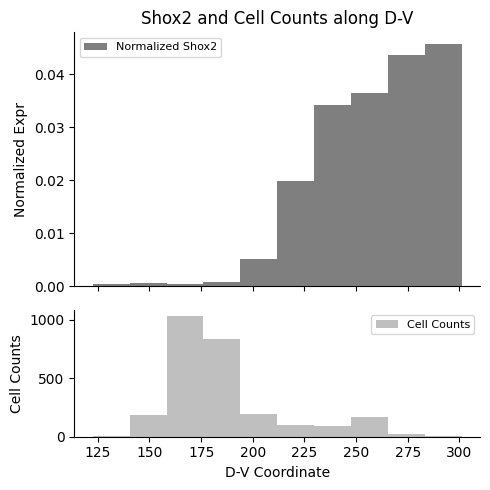

In [347]:
fig, (ax_top, ax_bottom) = plt.subplots(
    nrows=2, ncols=1, sharex=True, figsize=(5, 5),
    gridspec_kw={'height_ratios': [2, 1]}
)

# Top subplot: normalized gene expression bar plot
ax_top.bar(bin_centers, normalized_expr, width=(bins[1]-bins[0]),
           alpha=0.5, color='k', label=f'Normalized {gene_name}')
ax_top.set_ylabel('Normalized Expr')
ax_top.legend(fontsize=8)
ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)
ax_top.set_title(f'{gene_name} and Cell Counts along D-V')

ax_bottom.bar(bin_centers, cell_counts, width=(bins[1]-bins[0]),
              alpha=0.5, color='gray', label='Cell Counts')
ax_bottom.set_xlabel('D-V Coordinate')
ax_bottom.set_ylabel('Cell Counts')
ax_bottom.legend(fontsize=8)
ax_bottom.spines["top"].set_visible(False)
ax_bottom.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

/scratch/fast/48188/ipykernel_255720/41794934.py:56: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts
/scratch/fast/48188/ipykernel_255720/41794934.py:56: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts
/scratch/fast/48188/ipykernel_255720/41794934.py:56: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts
/scratch/fast/48188/ipykernel_255720/41794934.py:56: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts
/scratch/fast/48188/ipykernel_255720/41794934.py:56: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts


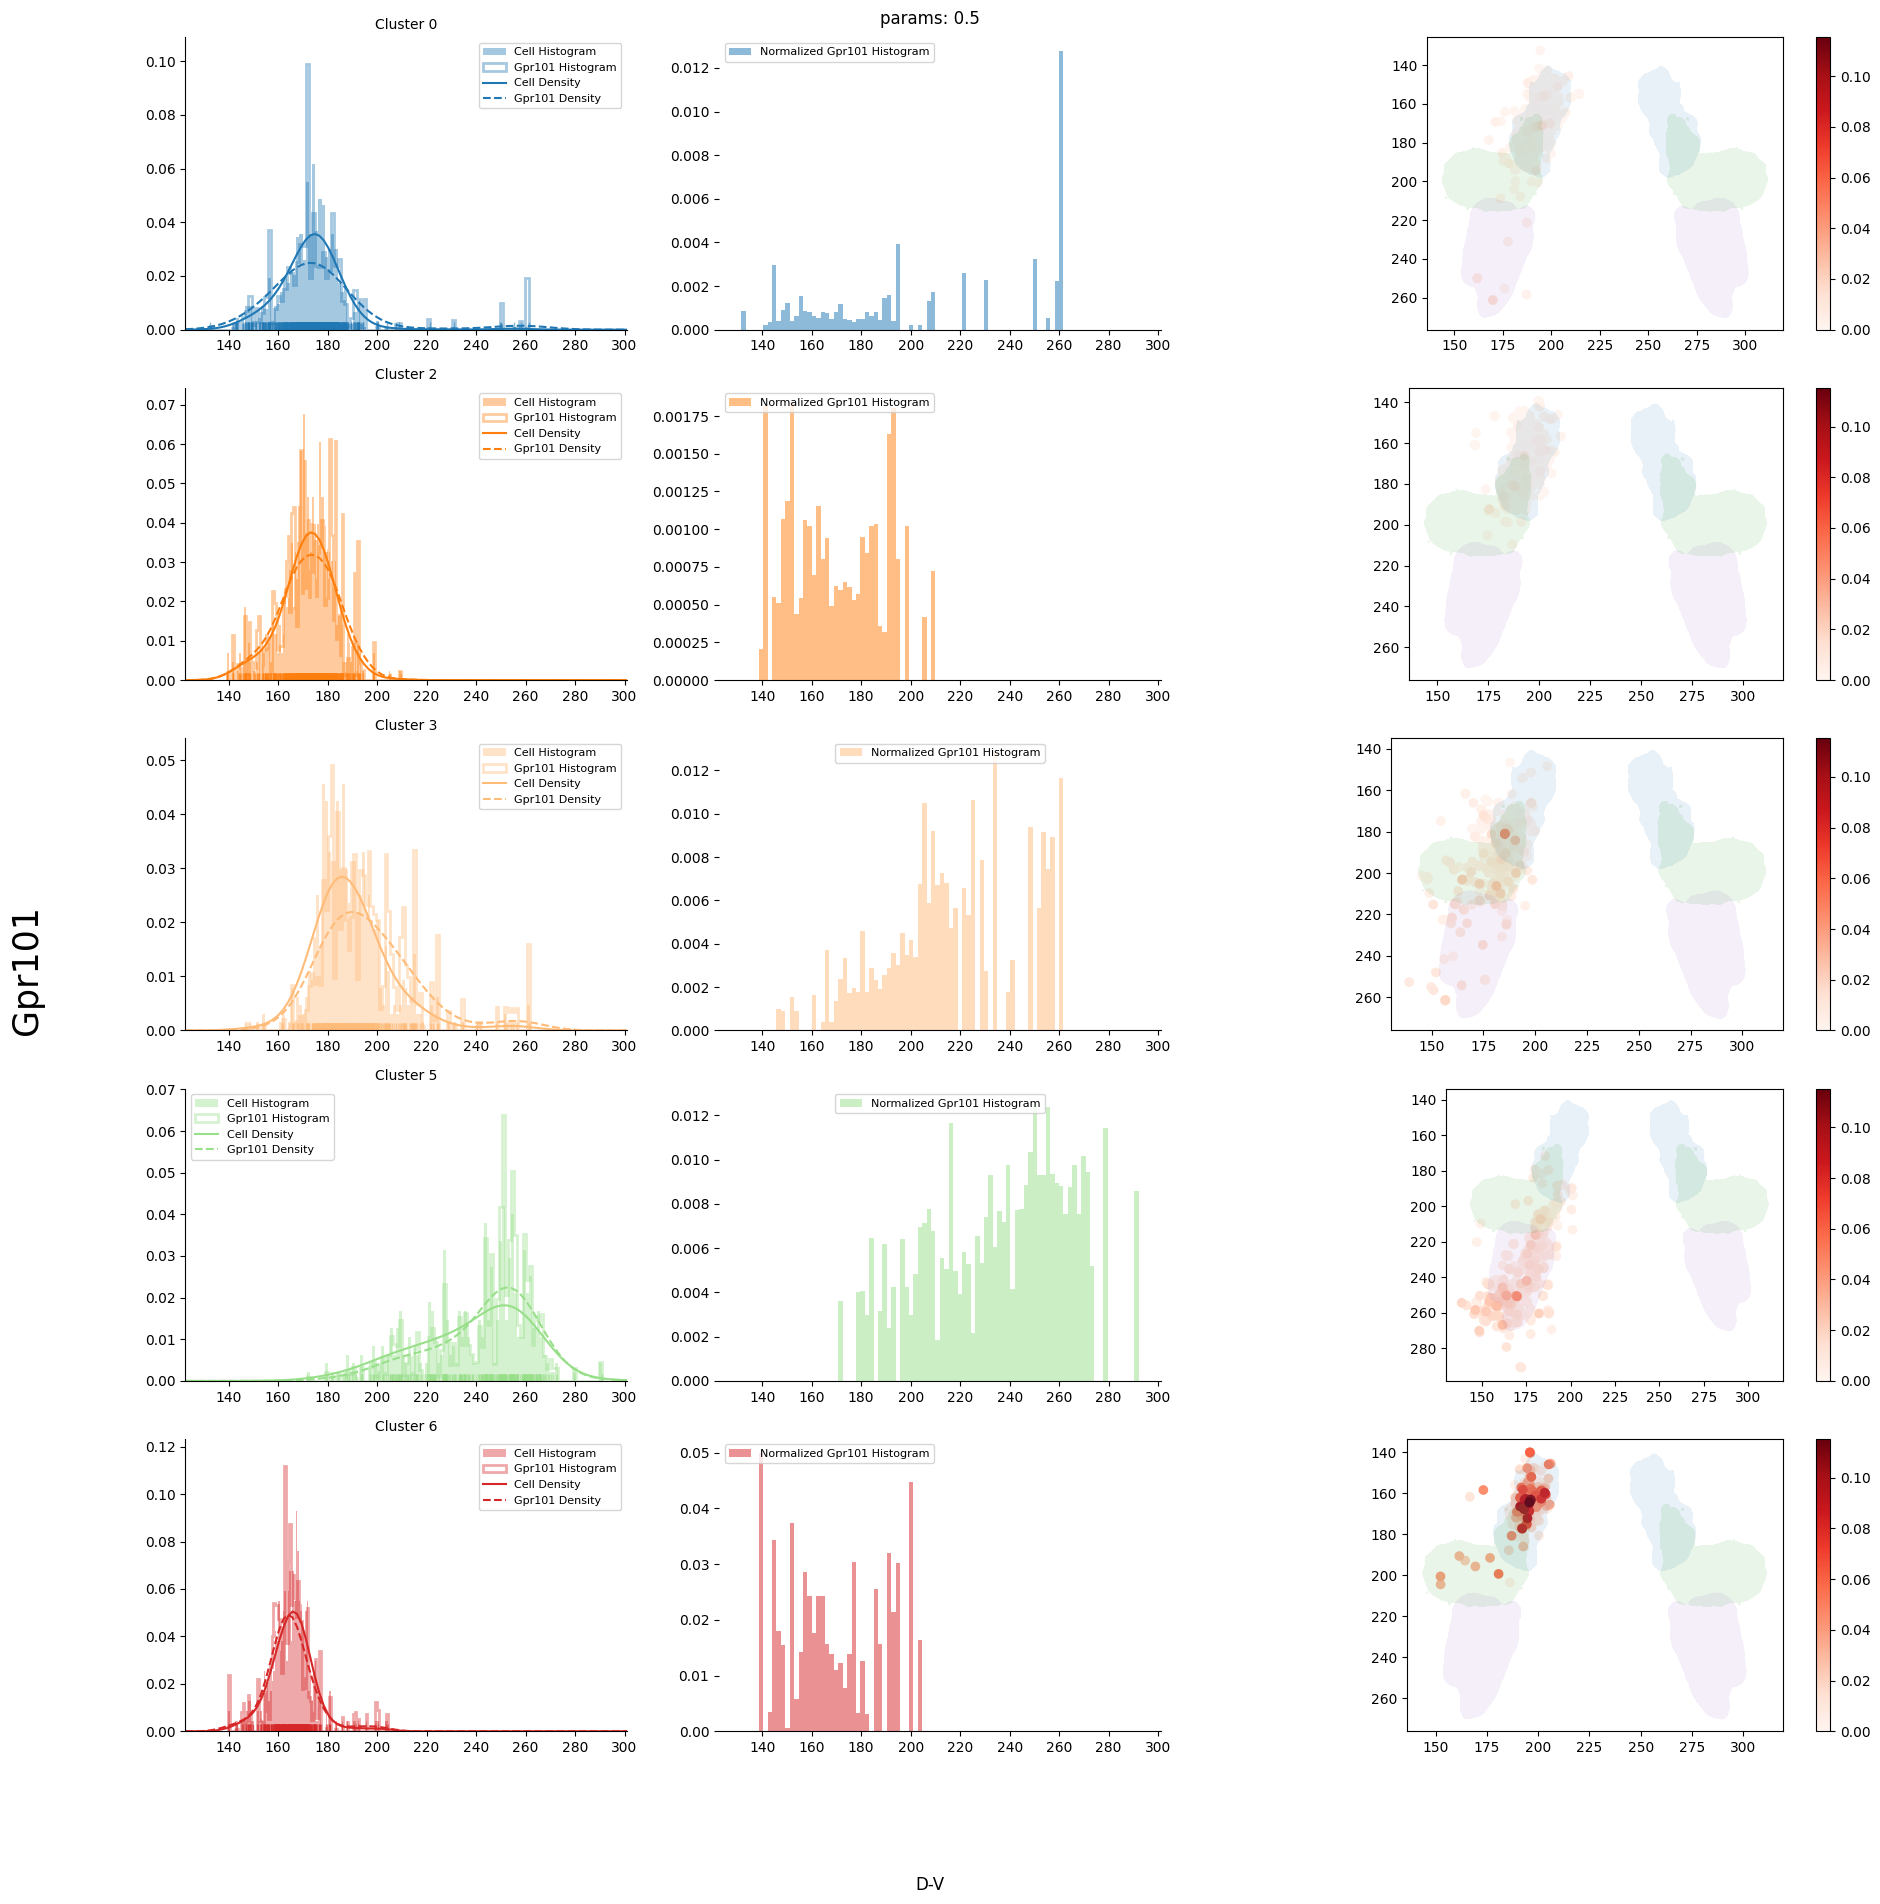

/scratch/fast/48188/ipykernel_255720/41794934.py:56: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts
/scratch/fast/48188/ipykernel_255720/41794934.py:56: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts
/scratch/fast/48188/ipykernel_255720/41794934.py:56: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts
/scratch/fast/48188/ipykernel_255720/41794934.py:56: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts
/scratch/fast/48188/ipykernel_255720/41794934.py:56: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts


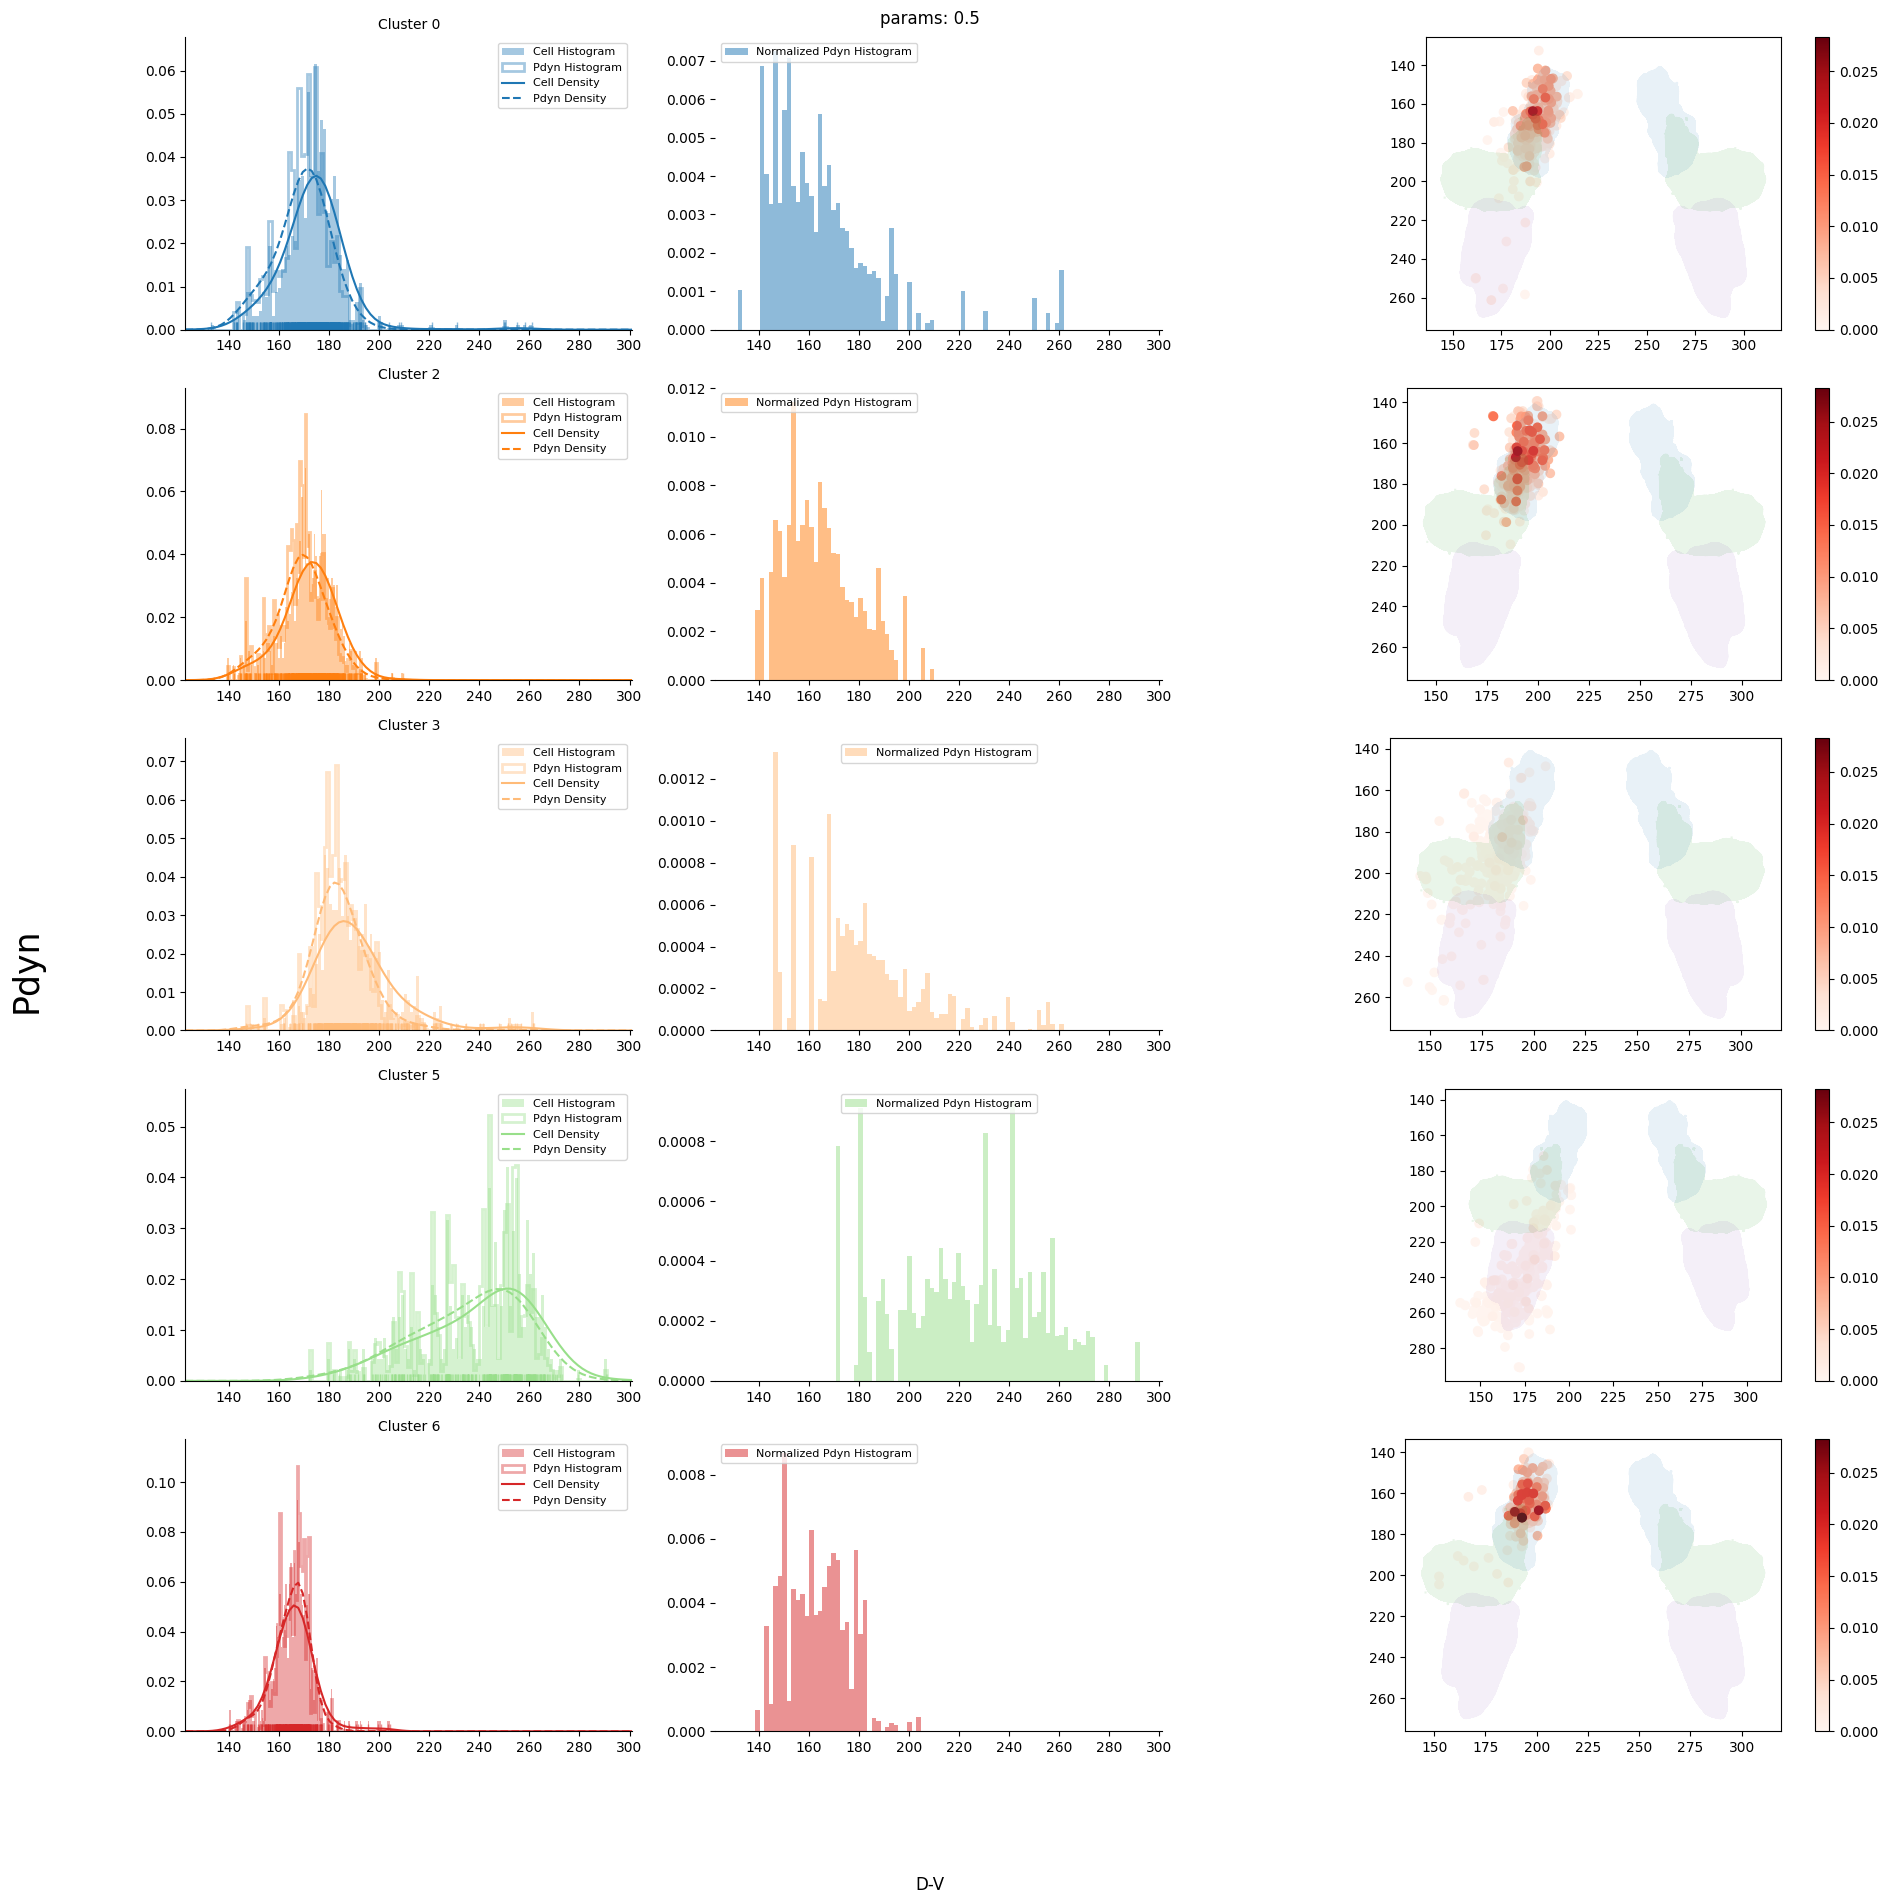

/scratch/fast/48188/ipykernel_255720/41794934.py:56: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts
/scratch/fast/48188/ipykernel_255720/41794934.py:56: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts
/scratch/fast/48188/ipykernel_255720/41794934.py:56: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts
/scratch/fast/48188/ipykernel_255720/41794934.py:56: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts
/scratch/fast/48188/ipykernel_255720/41794934.py:56: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts


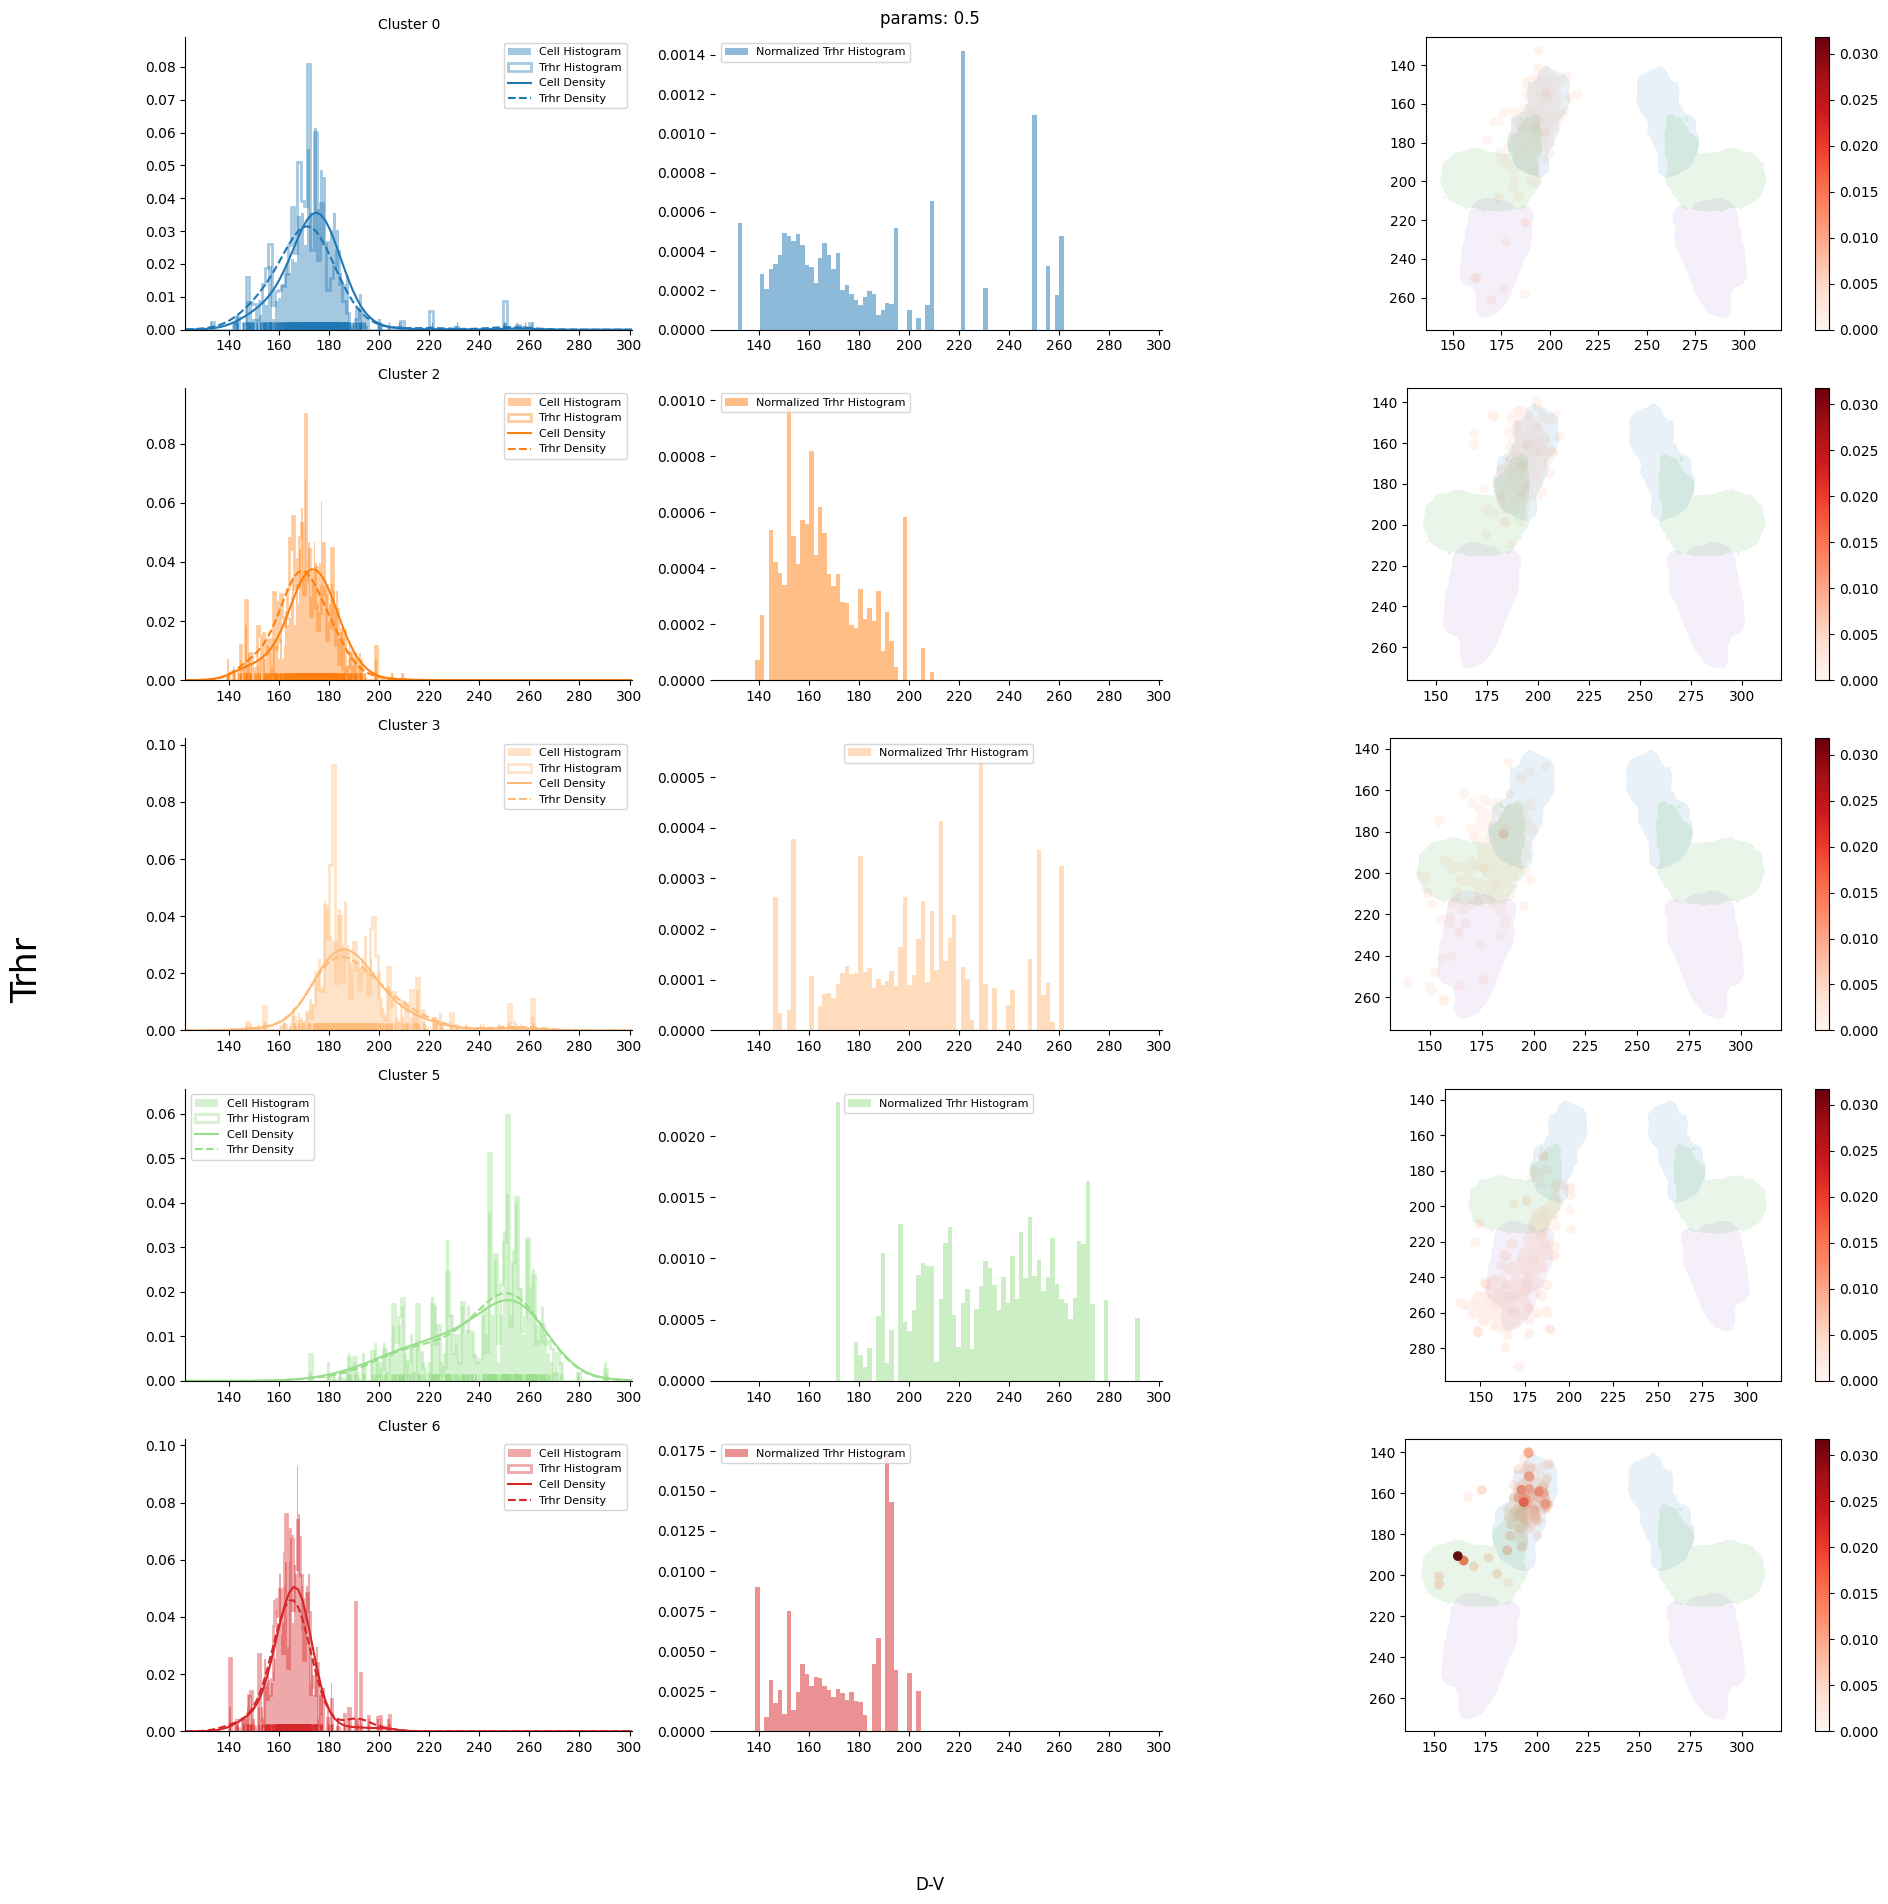

/scratch/fast/48188/ipykernel_255720/41794934.py:56: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts
/scratch/fast/48188/ipykernel_255720/41794934.py:56: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts
/scratch/fast/48188/ipykernel_255720/41794934.py:56: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts
/scratch/fast/48188/ipykernel_255720/41794934.py:56: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts
/scratch/fast/48188/ipykernel_255720/41794934.py:56: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts


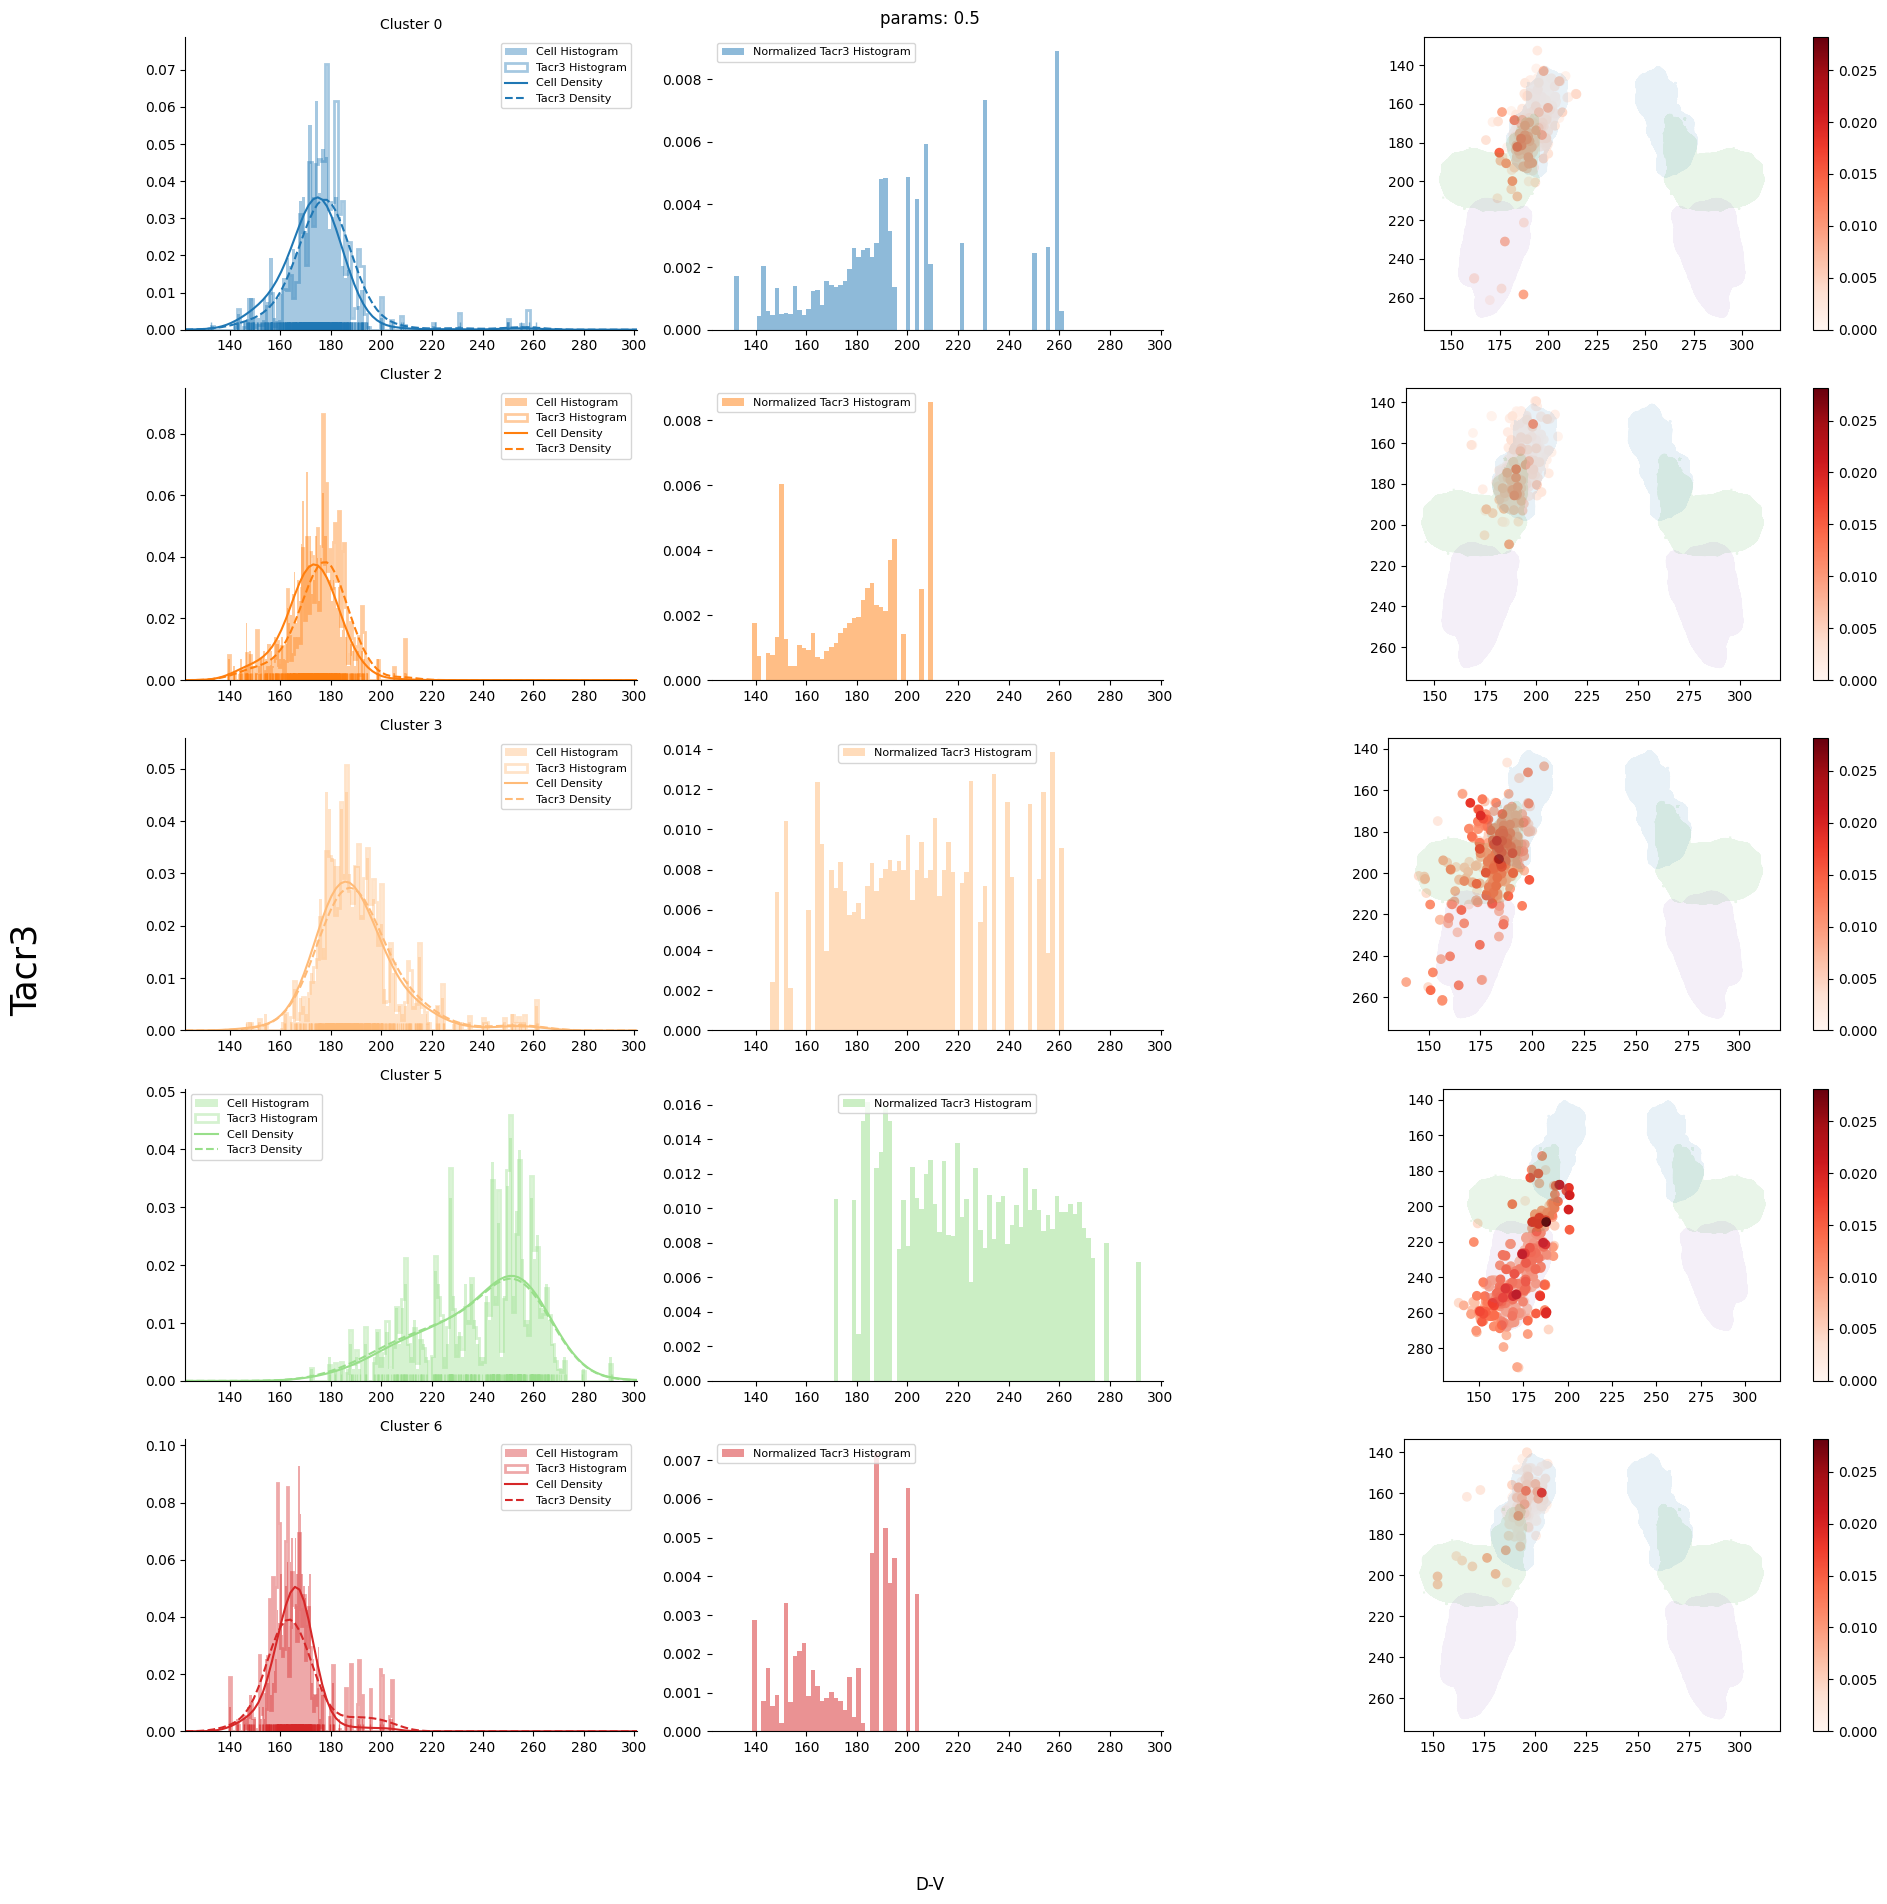

/scratch/fast/48188/ipykernel_255720/41794934.py:56: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts
/scratch/fast/48188/ipykernel_255720/41794934.py:56: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts
/scratch/fast/48188/ipykernel_255720/41794934.py:56: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts
/scratch/fast/48188/ipykernel_255720/41794934.py:56: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts
/scratch/fast/48188/ipykernel_255720/41794934.py:56: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts


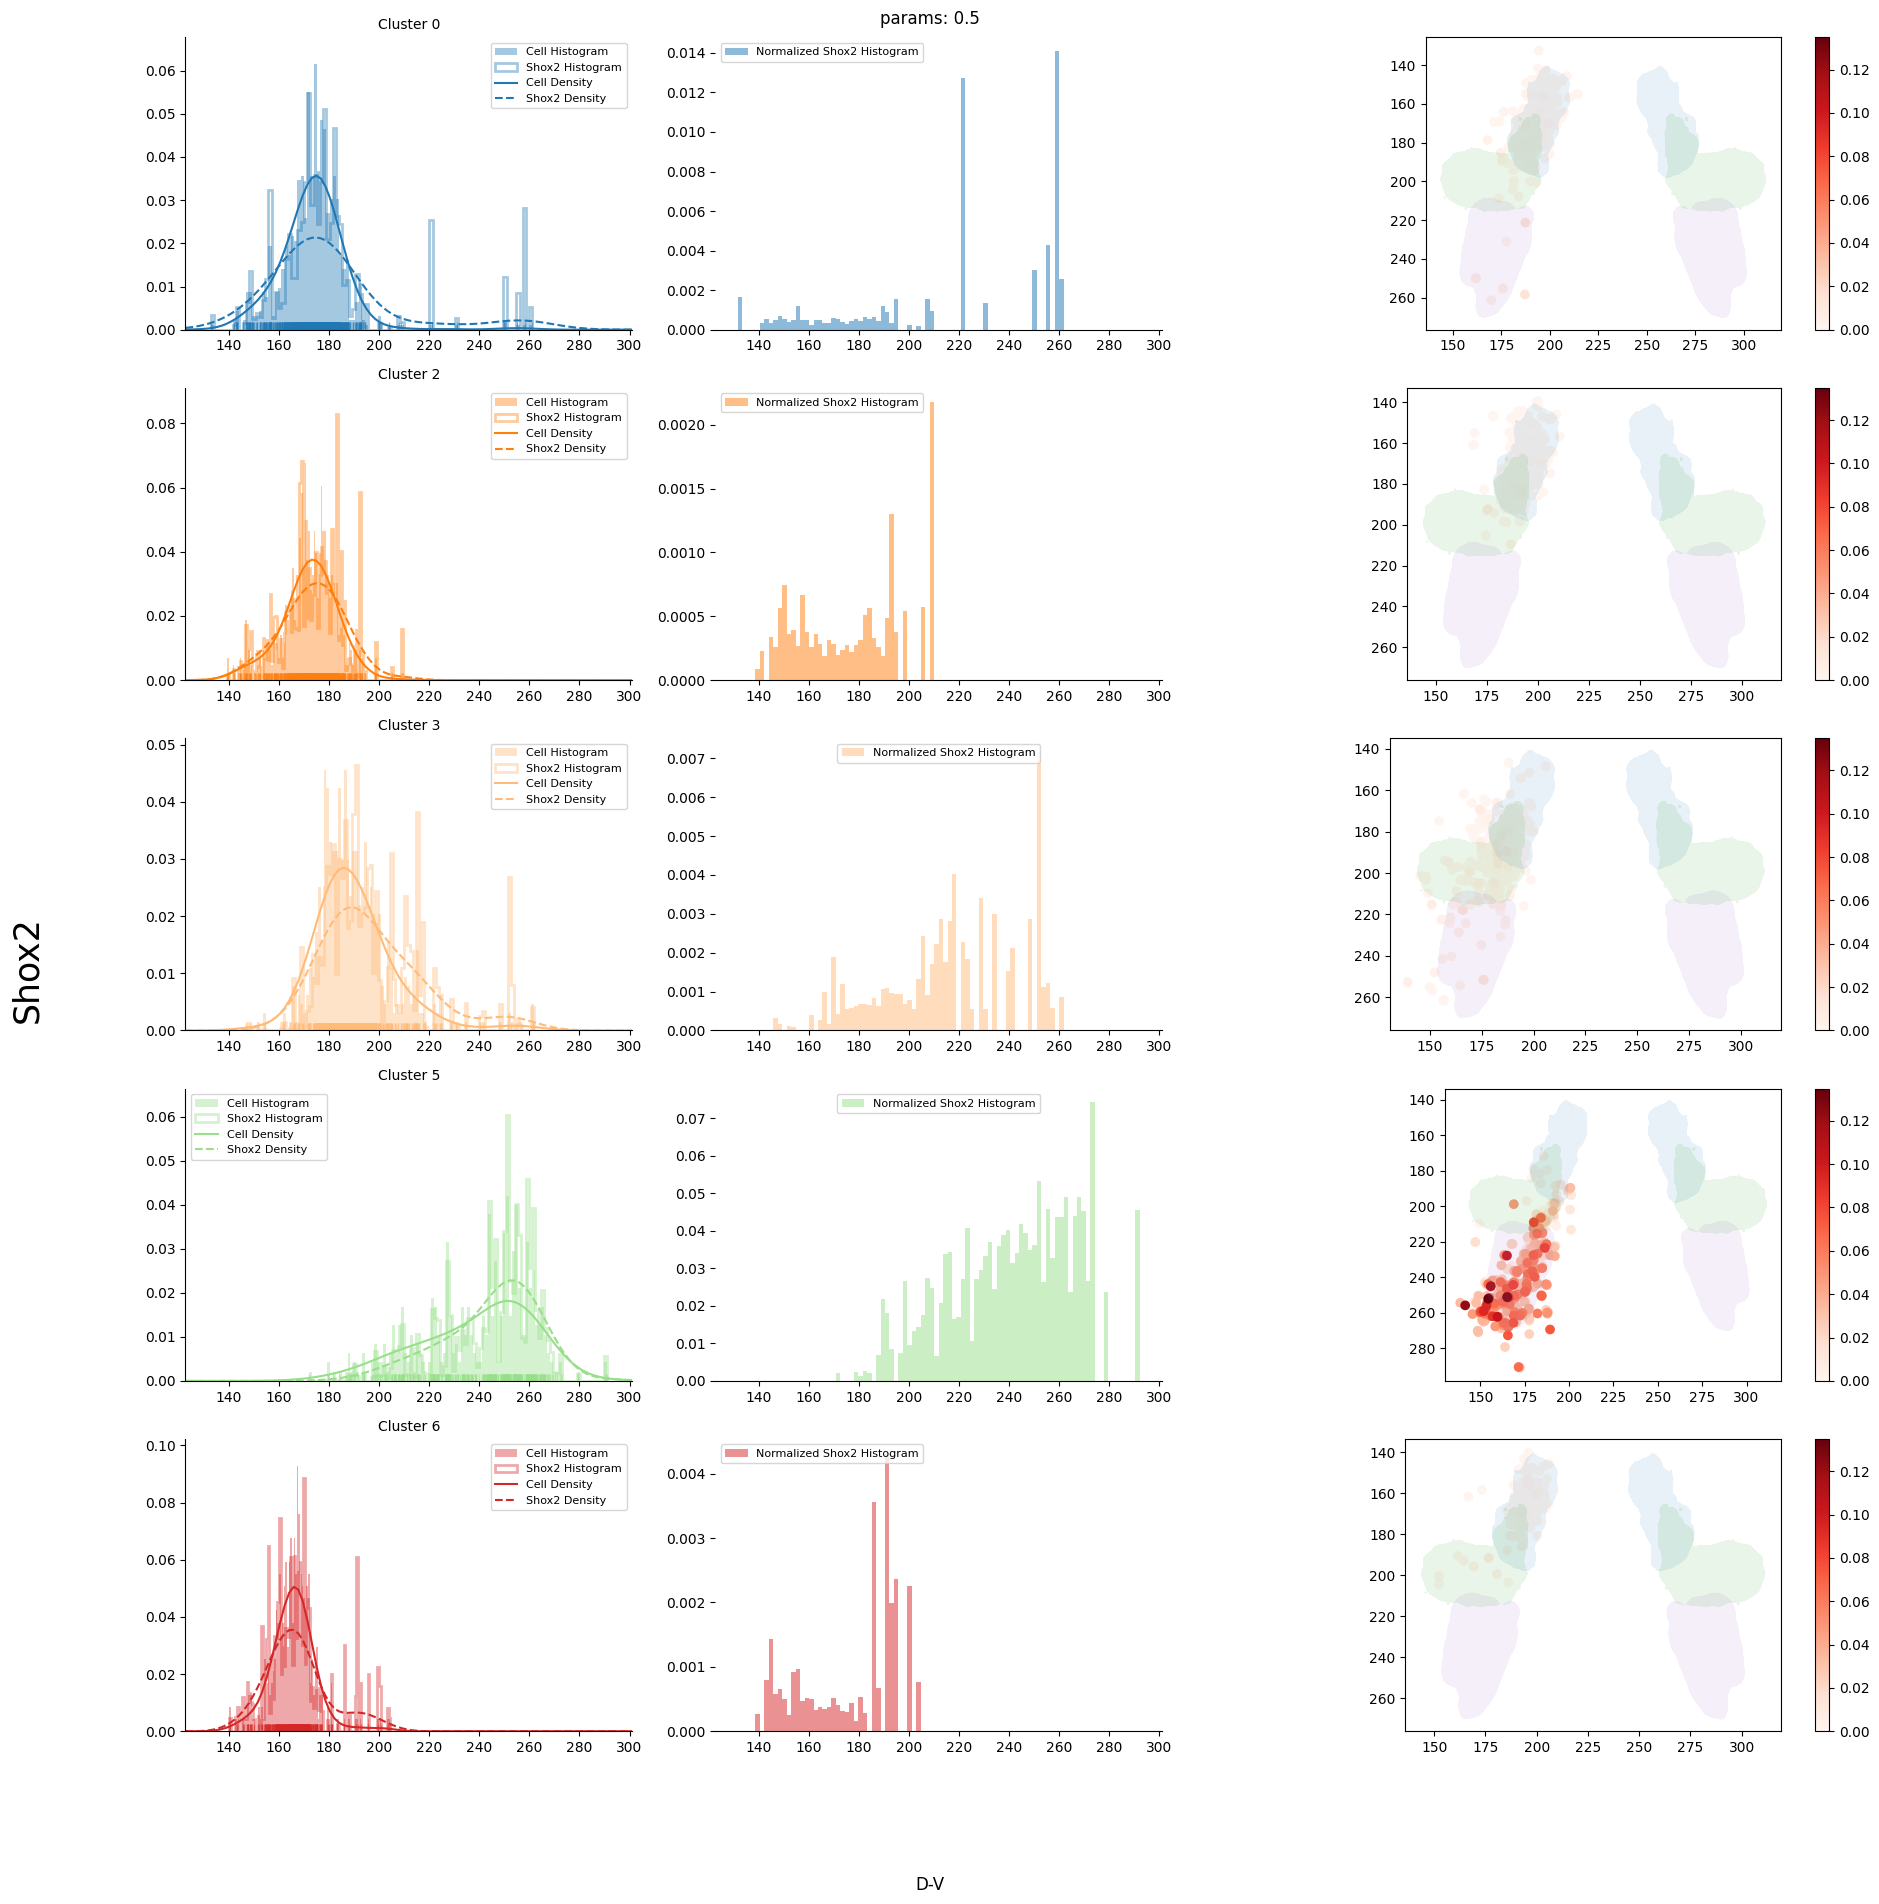

In [280]:
bw_method_params = 0.5
from scipy.stats import gaussian_kde

for g,gene_name in enumerate(intersted_genes):
    gene_idx = np.where(adata_sub.var_names == gene_name)[0][0]    
    max_exp = np.array(adata_mer[:,gene_name].X)[:,0].max()
    xmin = adata_mer.obsm['spatial'][:,1].min() - 10
    xmax = adata_mer.obsm['spatial'][:,1].max() + 10
    grid = np.linspace(xmin, xmax, 1000)
    fig, axes = plt.subplots(nrows=5, ncols=3, sharex=False, sharey=False, 
                             figsize=(20,20),gridspec_kw={'width_ratios': [1, 1, 1.5]})
    for m, (group_id, cell_id) in enumerate(groups.items()):
        adata_sub = adata_mer[cell_id]
        DV_coords = adata_sub.obsm['spatial'][:,1]    
        gene_expr = adata_sub.X[:, gene_idx]
        gene_expr = np.array(gene_expr).flatten()

        
        # compute KDE
        kde_cell = gaussian_kde(DV_coords, bw_method=bw_method_params)
        density_cell = kde_cell(grid)
        kde_expr = gaussian_kde(DV_coords, weights=gene_expr, bw_method=bw_method_params)
        density_expr = kde_expr(grid)

        num_bins = 10
        bins = np.linspace(xmin, xmax, num_bins+1)
        cell_counts, _ = np.histogram(DV_coords, bins=bins)
        weighted_counts, _ = np.histogram(DV_coords, bins=bins, weights=gene_expr)        
        bin_centers = 0.5 * (bins[:-1] + bins[1:])

        normalized_expr = density_expr / (density_cell + 1e-10)  # epsilon avoids division by zero
        
        axes[m,1].get_shared_x_axes().joined(axes[m,0], axes[m,1])
        ax = axes[m, 0]
        ax.hist(DV_coords, bins=num_bins, density=True,
                alpha=0.4, color=default_colors[int(group_id)],
                label='Cell Histogram')
        ax.hist(DV_coords, bins=num_bins, weights=gene_expr, density=True, alpha=0.4,
                color=default_colors[int(group_id)], histtype='step', linewidth=2, label=f'{gene_name} Histogram')
        ax.plot(grid, density_cell, label='Cell Density', color=default_colors[int(group_id)])
        ax.plot(grid, density_expr, label=f'{gene_name} Density', color=default_colors[int(group_id)], linestyle='--')
        sns.rugplot(x=DV_coords, 
                    color=default_colors[int(group_id)], alpha=0.5, ax=ax)

        ax.set_title(f'Cluster {group_id}', fontsize=10)
        ax.set_xlim(xmin, xmax)
        ax.legend(fontsize=8)
        ax.set_xlabel('');ax.set_ylabel('')    
        ax.spines["top"].set_visible(False);
        ax.spines["right"].set_visible(False)


        ax = axes[m, 1]
        norm_hist = weighted_counts / (cell_counts + 1e-20)
        mean_density = weighted_counts/cell_counts
        ax.bar(bin_centers, mean_density, width=(bins[1]-bins[0]),
            alpha=0.5, color=default_colors[int(group_id)], label=f'Normalized {gene_name} Histogram')

        ax.set_xlim(xmin, xmax)
        ax.legend(fontsize=8)
        ax.set_xlabel('');ax.set_ylabel('')    
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False),; ax.spines["left"].set_visible(False)

        ax = axes[m, 2]
        allexpressionvalues = np.array(adata_sub[:,gene_name].X)[:,0]
        cellorders = np.argsort(allexpressionvalues)
        scat = ax.scatter(adata_sub.obsm['spatial'][cellorders,2],adata_sub.obsm['spatial'][cellorders,1],cmap ='Reds',
                             c=allexpressionvalues[cellorders], vmax = max_exp,vmin = 0)    
        plt.colorbar(scat)
        ax.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
        ax.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
        ax.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
        ax.invert_yaxis()
        ax.set_aspect('equal')
        ax.set_xlabel('');ax.set_ylabel('')    


    fig.text(0.5, 0.04, 'D-V', ha='center', fontsize=12)
    fig.text(0.04, 0.5, f'{gene_name}', va='center', rotation='vertical', fontsize=25)
    fig.suptitle(f'params: {bw_method_params}')
    fig.tight_layout()
    plt.tight_layout(rect=[0.1, 0.1, 1, 1])
    plt.show()


In [286]:
plt.hist??

In [281]:
bins.shape

(101,)

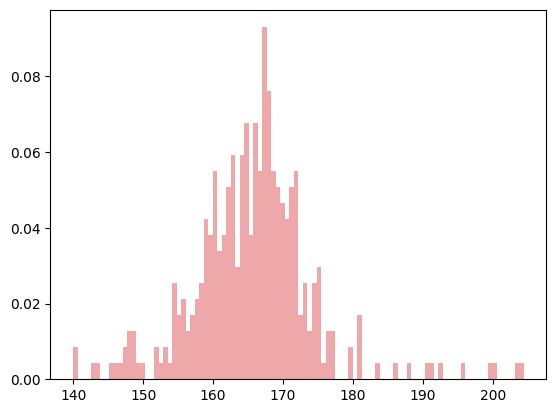

In [287]:
foo = plt.hist(DV_coords, bins=num_bins, density=True,
                alpha=0.4, color=default_colors[int(group_id)],
                label='Cell Histogram')

In [289]:
foo[0]

array([0.0084508, 0.       , 0.       , 0.       , 0.0042254, 0.0042254,
       0.       , 0.       , 0.0042254, 0.0042254, 0.0042254, 0.0084508,
       0.0126762, 0.0126762, 0.0042254, 0.0042254, 0.       , 0.       ,
       0.0084508, 0.0042254, 0.0084508, 0.0042254, 0.0253524, 0.0169016,
       0.021127 , 0.0126762, 0.0169016, 0.021127 , 0.0253524, 0.042254 ,
       0.0380286, 0.0549302, 0.0338032, 0.0380286, 0.0507048, 0.0591556,
       0.0295778, 0.0591556, 0.0676064, 0.0380286, 0.0676064, 0.0549302,
       0.0929588, 0.0760572, 0.0549302, 0.0507048, 0.0464794, 0.042254 ,
       0.0507048, 0.0549302, 0.0169016, 0.0253524, 0.0126762, 0.0253524,
       0.0295778, 0.0042254, 0.0126762, 0.0126762, 0.       , 0.       ,
       0.       , 0.0084508, 0.       , 0.0169016, 0.       , 0.       ,
       0.       , 0.0042254, 0.       , 0.       , 0.       , 0.0042254,
       0.       , 0.       , 0.0042254, 0.       , 0.       , 0.       ,
       0.0042254, 0.0042254, 0.       , 0.0042254, 

In [290]:
foo1 = np.histogram(DV_coords, bins=num_bins, density=True,)

In [291]:
foo1[0]

array([0.0084508, 0.       , 0.       , 0.       , 0.0042254, 0.0042254,
       0.       , 0.       , 0.0042254, 0.0042254, 0.0042254, 0.0084508,
       0.0126762, 0.0126762, 0.0042254, 0.0042254, 0.       , 0.       ,
       0.0084508, 0.0042254, 0.0084508, 0.0042254, 0.0253524, 0.0169016,
       0.021127 , 0.0126762, 0.0169016, 0.021127 , 0.0253524, 0.042254 ,
       0.0380286, 0.0549302, 0.0338032, 0.0380286, 0.0507048, 0.0591556,
       0.0295778, 0.0591556, 0.0676064, 0.0380286, 0.0676064, 0.0549302,
       0.0929588, 0.0760572, 0.0549302, 0.0507048, 0.0464794, 0.042254 ,
       0.0507048, 0.0549302, 0.0169016, 0.0253524, 0.0126762, 0.0253524,
       0.0295778, 0.0042254, 0.0126762, 0.0126762, 0.       , 0.       ,
       0.       , 0.0084508, 0.       , 0.0169016, 0.       , 0.       ,
       0.       , 0.0042254, 0.       , 0.       , 0.       , 0.0042254,
       0.       , 0.       , 0.0042254, 0.       , 0.       , 0.       ,
       0.0042254, 0.0042254, 0.       , 0.0042254, 

# test

In [268]:
mean_density = weighted_counts/cell_counts

/scratch/fast/48188/ipykernel_255720/1026442585.py:1: RuntimeWarning: invalid value encountered in divide
  mean_density = weighted_counts/cell_counts


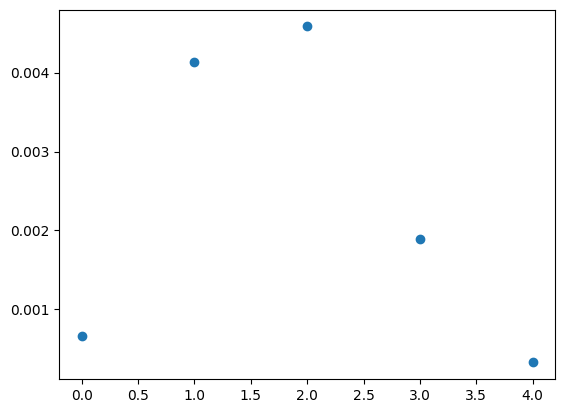

In [271]:
plt.plot(mean_density,'o')

<BarContainer object of 10 artists>

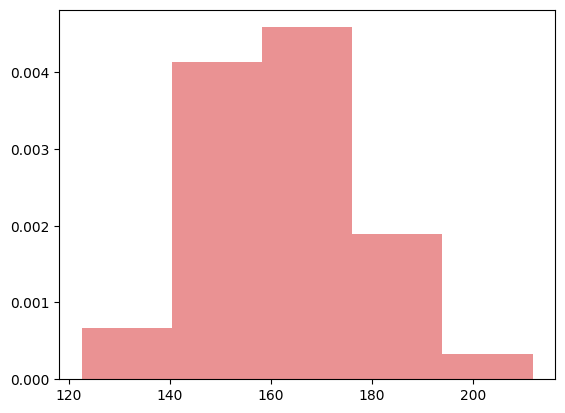

In [274]:
plt.bar(bin_centers, mean_density, width=(bins[1]-bins[0]),
            alpha=0.5, color=default_colors[int(group_id)], label=f'Normalized {gene_name} Histogram')

In [277]:
bins

array([122.58497736, 140.4277209 , 158.27046445, 176.11320799,
       193.95595153, 211.79869508, 229.64143862, 247.48418217,
       265.32692571, 283.16966925, 301.0124128 ])

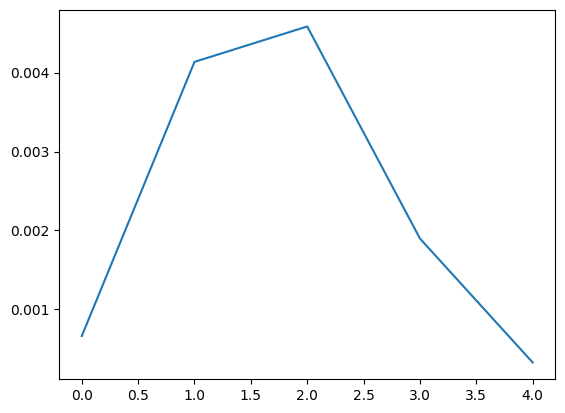

In [276]:
plt.plot(mean_density)

In [ ]:
np.histogram

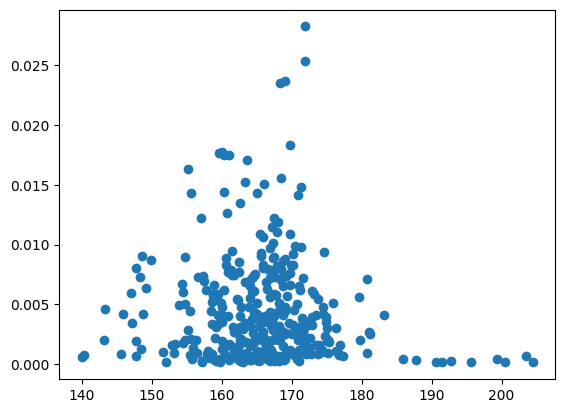

In [189]:
plt.scatter(DV_coords,gene_expr)

In [190]:
.shape

(3,)

In [191]:
weighted_counts.sum()

np.float32(1.5832235)

In [192]:
(weighted_counts*cell_counts).sum()

np.float64(561.2082446813583)

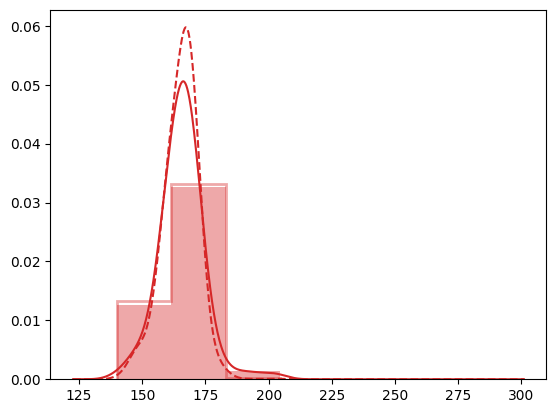

In [193]:
plt.hist(DV_coords, bins=num_bins, density=True, alpha=0.4, color=default_colors[int(group_id)],
        label='Cell Histogram')
plt.hist(DV_coords, bins=num_bins, weights=gene_expr, density=True, alpha=0.4,
        color=default_colors[int(group_id)], histtype='step', linewidth=2, label=f'{gene_name} Histogram')
plt.plot(grid, density_cell, label='Cell Density', color=default_colors[int(group_id)])
plt.plot(grid, density_expr, label=f'{gene_name} Density', color=default_colors[int(group_id)], linestyle='--')


In [197]:
density_cell.sum()

np.float64(5.598914062756462)

In [ ]:




norm_hist = weighted_counts / (cell_counts + 1e-20)  # add epsilon to avoid division by zero


normalized_expr = density_expr / (density_cell + 1e-10)  # epsilon avoids division by zero


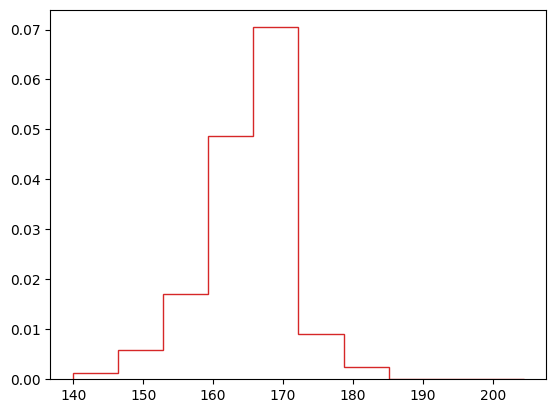

In [157]:
plt.hist(DV_coords, bins=num_bins, weights=gene_expr, density=True,
         color=default_colors[int(group_id)], histtype='step') ;

In [159]:
num_bins

10

In [153]:
gene_expr.shape

(367,)

# try to find the other genes that are relevant on DV-axis ? 

In [126]:
from scipy.stats import spearmanr

In [127]:
DV = adata_sub.obsm['spatial'][:, 0]
if hasattr(adata_sub.X, "toarray"):
    X = adata_sub.X.toarray()
else:
    X = np.array(adata_sub.X)
gene_names = adata_sub.var_names
results = []
for i, gene in enumerate(gene_names):
    expr = X[:, i].flatten()
#     corr, pval = pearsonr(expr, DV)
    corr, pval = spearmanr(expr, DV)
    results.append((gene, corr, pval))


In [128]:
df_results = pd.DataFrame(results, columns=['gene', 'correlation', 'pvalue'])

# Optionally, sort by the absolute value of the correlation coefficient (largest first)
df_results = df_results.sort_values(by='correlation', key=lambda s: s.abs(), ascending=False)

# Display the top genes associated with the DV coordinate
print(df_results.head(10))


         gene  correlation        pvalue
161      Nefh    -0.417368  6.676577e-17
79       Ebf1    -0.399701  1.645514e-15
275   Tmem178    -0.384240  2.333511e-14
223     Robo3     0.367015  3.814379e-13
219      Rgs5    -0.356631  1.899976e-12
134     Itih5    -0.355266  2.336303e-12
61     Col9a1     0.348802  6.136932e-12
212    Prss23    -0.344836  1.097911e-11
7    Adamts19    -0.327088  1.342964e-10
126      Htr7    -0.324439  1.925101e-10


In [125]:
df_results = pd.DataFrame(results, columns=['gene', 'correlation', 'pvalue'])

# Optionally, sort by the absolute value of the correlation coefficient (largest first)
df_results = df_results.sort_values(by='correlation', key=lambda s: s.abs(), ascending=False)

# Display the top genes associated with the DV coordinate
print(df_results.head(10))


        gene  correlation        pvalue
161     Nefh    -0.478258  2.249420e-22
275  Tmem178    -0.437326  1.414208e-18
77    Dnah12    -0.404328  7.240099e-16
212   Prss23    -0.397532  2.407020e-15
119      Grp    -0.385987  1.741223e-14
294     Zeb2    -0.377592  6.995579e-14
237    Shox2    -0.358612  1.404933e-12
234   Sema3a    -0.348088  6.818576e-12
219     Rgs5    -0.346029  9.223827e-12
307    Kcna1    -0.344572  1.140840e-11


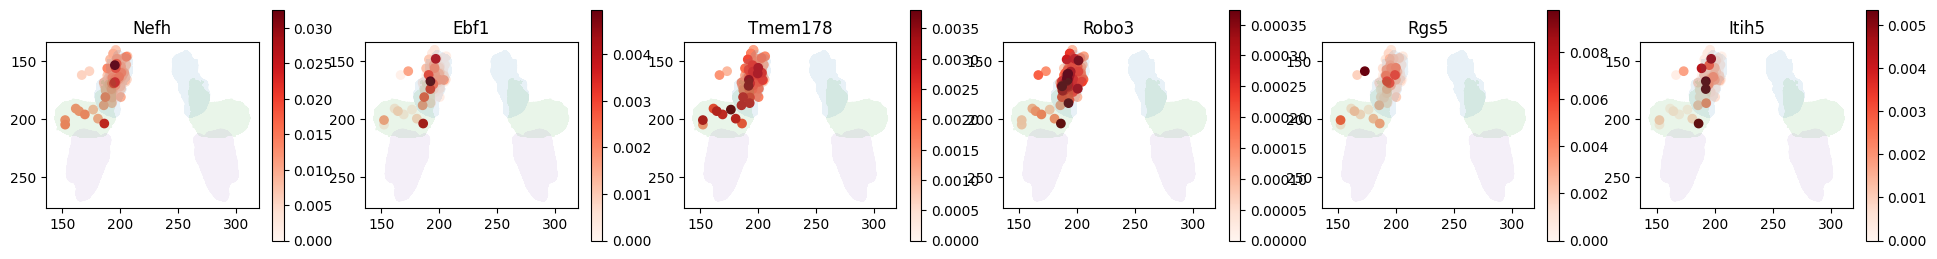

In [147]:
T = 6
fig, axes = plt.subplots(1,T,figsize = (4*T,3))
for i,gene_name in enumerate(df_results['gene'][:T]):
    ax =axes[i]
    allexpressionvalues = np.array(adata_sub[:,gene_name].X)[:,0]
    cellorders = np.argsort(allexpressionvalues)
    scat = ax.scatter(adata_sub.obsm['spatial'][cellorders,2],adata_sub.obsm['spatial'][cellorders,1],cmap ='Reds',
                         c=allexpressionvalues[cellorders], 
                      vmax = allexpressionvalues.max()*.8,vmin = 0)    
    plt.colorbar(scat)
    ax.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    ax.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    ax.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.set_xlabel('');ax.set_ylabel('')    
    ax.set_title(gene_name)

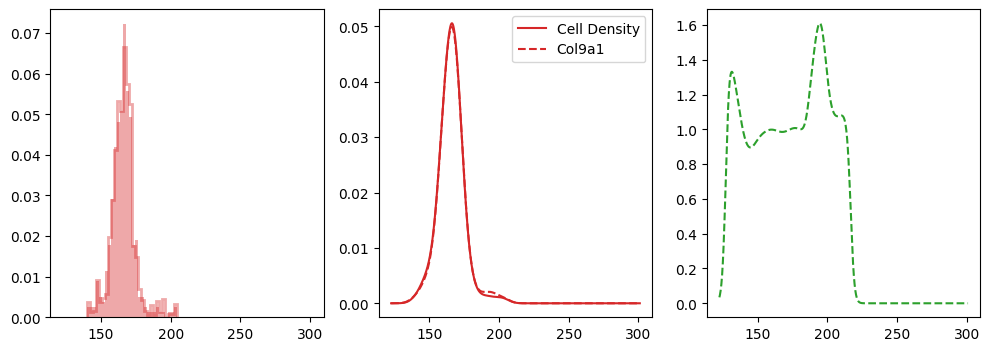

In [148]:

gene_name = 'Col9a1'

gene_idx = np.where(adata_sub.var_names == gene_name)[0][0]    


adata_sub = adata_mer[cell_id]
DV_coords = adata_sub.obsm['spatial'][:,1]

gene_expr = adata_sub.X[:, gene_idx]
gene_expr = np.array(gene_expr).flatten()
        
kde_cell = gaussian_kde(DV_coords, bw_method=bw_method_params)
density_cell = kde_cell(grid)

kde_expr = gaussian_kde(DV_coords, weights=gene_expr, bw_method=bw_method_params)
density_expr = kde_expr(grid)

    
fig, axes = plt.subplots(nrows=1, ncols=3, sharex=True, sharey=False, figsize=(12,4))    
ax = axes[0]
ax.hist(DV_coords, bins=30, density=True, alpha=0.4, color=default_colors[int(group_id)],
        label='Cell Histogram')
ax.hist(DV_coords, bins=30, weights=gene_expr, density=True, alpha=0.4,
        color=default_colors[int(group_id)], histtype='step', linewidth=2, label='Gpr101 Histogram')

ax = axes[1]
ax.plot(grid, density_cell, label='Cell Density', color=default_colors[int(group_id)])
ax.plot(grid, density_expr, label=gene_name, color=default_colors[int(group_id)], linestyle='--')
ax.legend()

axes[2].plot(grid,density_expr/(density_cell+1e-5),'--', color=default_colors[m])

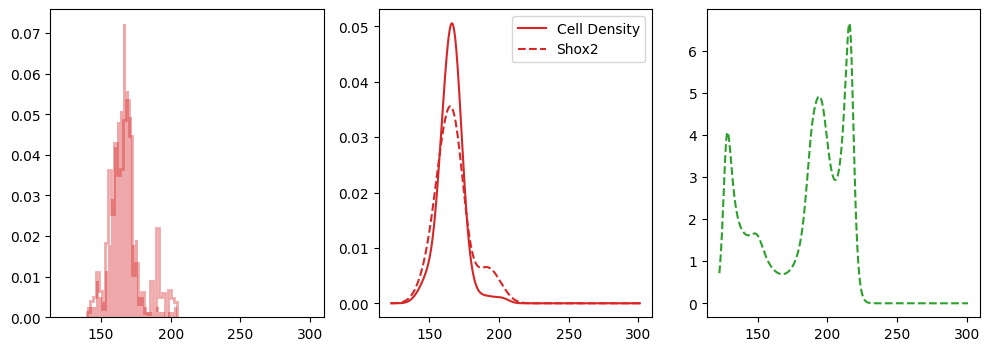

In [149]:
gene_name = 'Shox2'

gene_idx = np.where(adata_sub.var_names == gene_name)[0][0]    
adata_sub = adata_mer[cell_id]
DV_coords = adata_sub.obsm['spatial'][:,1]

gene_expr = adata_sub.X[:, gene_idx]
gene_expr = np.array(gene_expr).flatten()
        
kde_cell = gaussian_kde(DV_coords, bw_method=bw_method_params)
density_cell = kde_cell(grid)

kde_expr = gaussian_kde(DV_coords, weights=gene_expr, bw_method=bw_method_params)
density_expr = kde_expr(grid)

    
fig, axes = plt.subplots(nrows=1, ncols=3, sharex=True, sharey=False, figsize=(12,4))    
ax = axes[0]
ax.hist(DV_coords, bins=30, density=True, alpha=0.4, color=default_colors[int(group_id)],
        label='Cell Histogram')
ax.hist(DV_coords, bins=30, weights=gene_expr, density=True, alpha=0.4,
        color=default_colors[int(group_id)], histtype='step', linewidth=2, label='Gpr101 Histogram')

ax = axes[1]
ax.plot(grid, density_cell, label='Cell Density', color=default_colors[int(group_id)])
ax.plot(grid, density_expr, label=gene_name, color=default_colors[int(group_id)], linestyle='--')
ax.legend()

axes[2].plot(grid,density_expr/(density_cell+1e-5),'--', color=default_colors[m])

In [ ]:
plt.plot(grid,density_expr-(density_cell+1e-5),'--', color=default_colors[m])

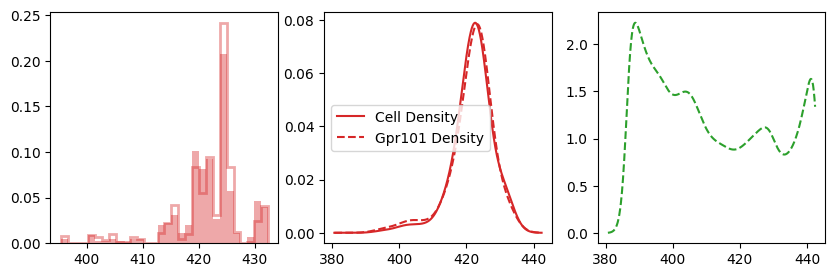

In [107]:
kde_cell = gaussian_kde(DV_coords, bw_method=bw_method_params)
density_cell = kde_cell(grid)

kde_expr = gaussian_kde(DV_coords, weights=gene_expr, bw_method=bw_method_params)
density_expr = kde_expr(grid)

    
    
plt.figure(figsize = (10,3))
plt.subplot(1,3,1);
plt.hist(DV_coords, bins=30, density=True, alpha=0.4, color=default_colors[int(group_id)],
        label='Cell Histogram')
plt.hist(DV_coords, bins=30, weights=gene_expr, density=True, alpha=0.4,
        color=default_colors[int(group_id)], histtype='step', linewidth=2, label='Gpr101 Histogram')

plt.subplot(1,3,2)
plt.plot(grid, density_cell, label='Cell Density', color=default_colors[int(group_id)])
plt.plot(grid, density_expr, label='Gpr101 Density', color=default_colors[int(group_id)], linestyle='--')
plt.legend()
plt.subplot(1,3,3);
plt.plot(grid,density_expr/(density_cell+1e-5),'--', color=default_colors[m])

In [ ]:
vmaxlist = list(np.max(adata_mer[:,intersted_genes].X, 0))
vmaxlist[2] = 0.01
with plt.rc_context({"figure.figsize": (3,3)}):    
    ax = sc.pl.embedding(adata_mer, dimensions = (2, 1),basis="spatial", cmap ='Reds',
                         vmax = vmaxlist,
                         color=intersted_genes,ncols =3, show=False)    
    for a in ax:
        a.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .2, label = 'LC')
        a.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .2, label = 'CD')
        a.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .2, label = 'CV')
        a.invert_yaxis()
        a.set_aspect('equal')
    fig.suptitle('original!!')
    plt.show()    
    

# cell gradient check 

In [ ]:
ax = sc.pl.embedding(adata_mer, basis = 'spatial', dimensions = (2,1), color = 'leiden', show = False)
ax.set_aspect('equal')
ax.invert_yaxis()
# ax.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
# ax.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
# ax.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')

In [166]:
adata_mer.raw

In [159]:
np.argmax(adata_mer[:,'Trhr'].X.flatten().toarray())

np.int64(1781)

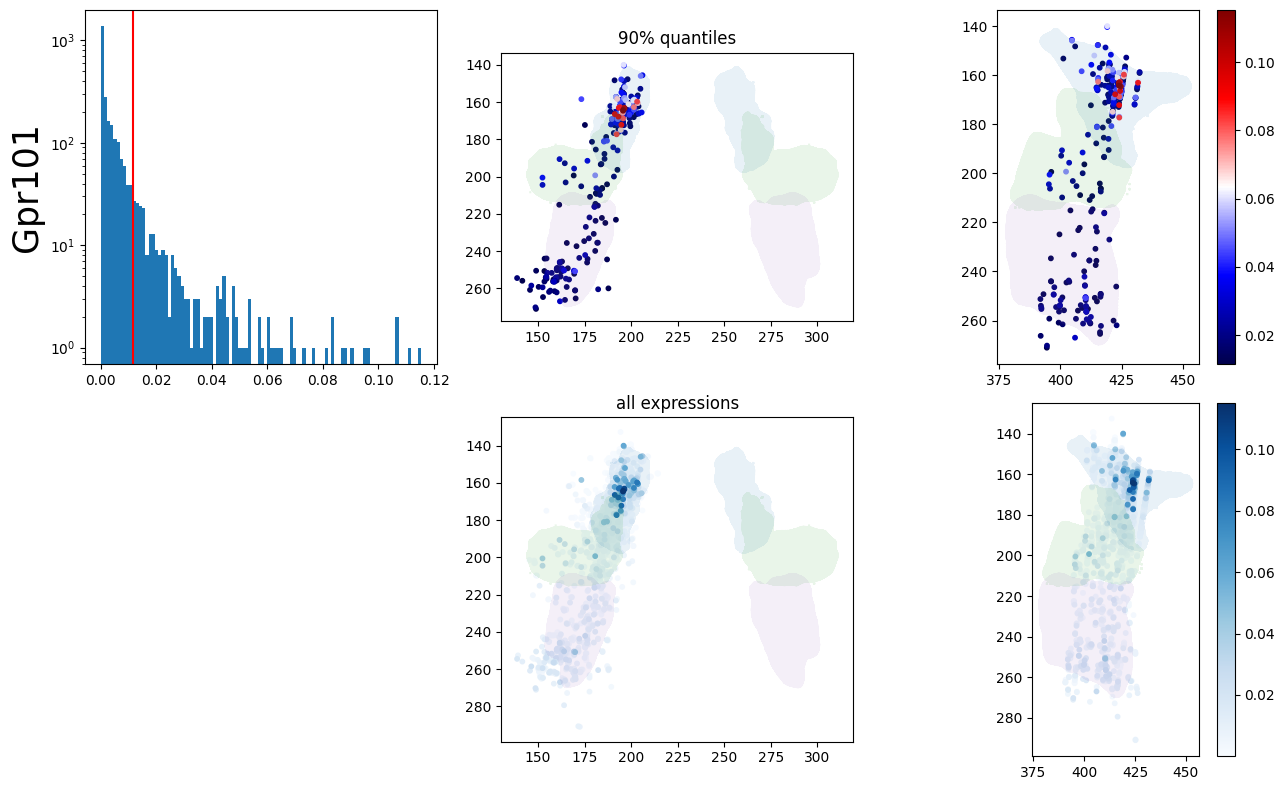

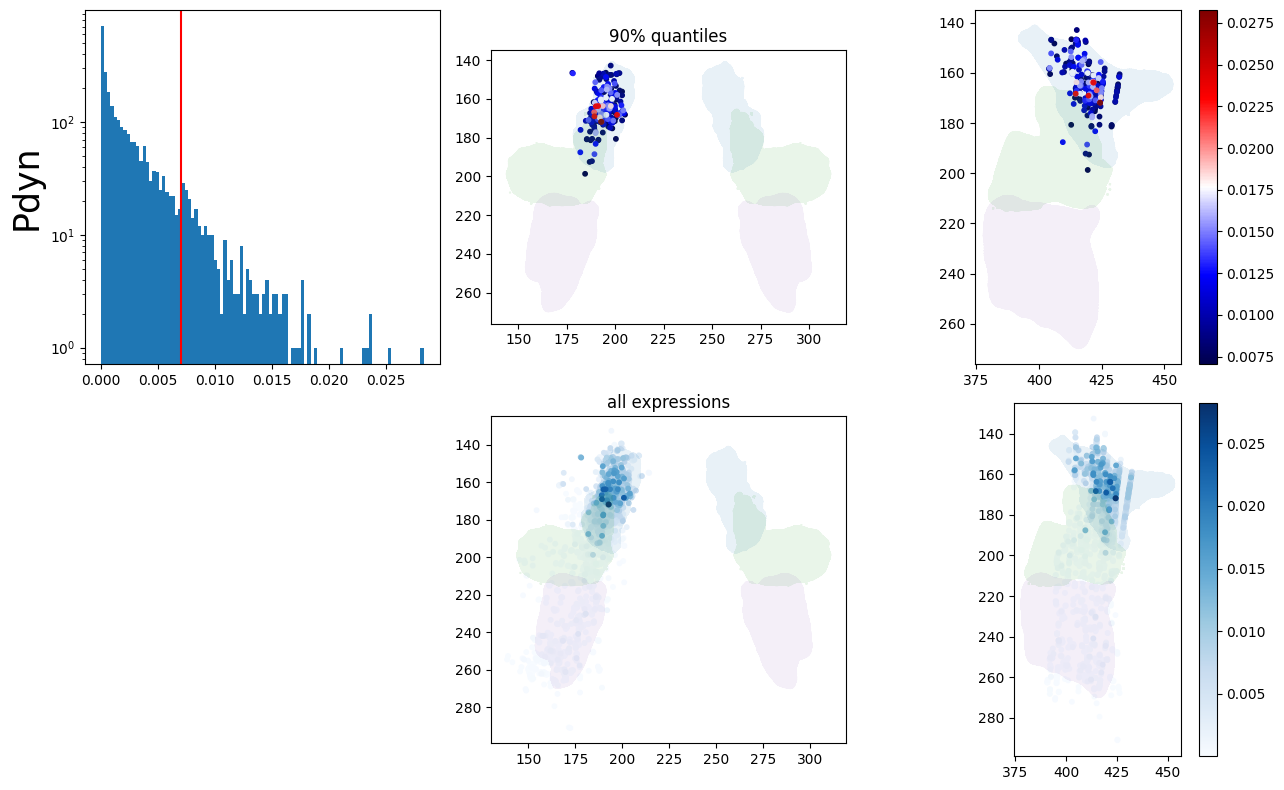

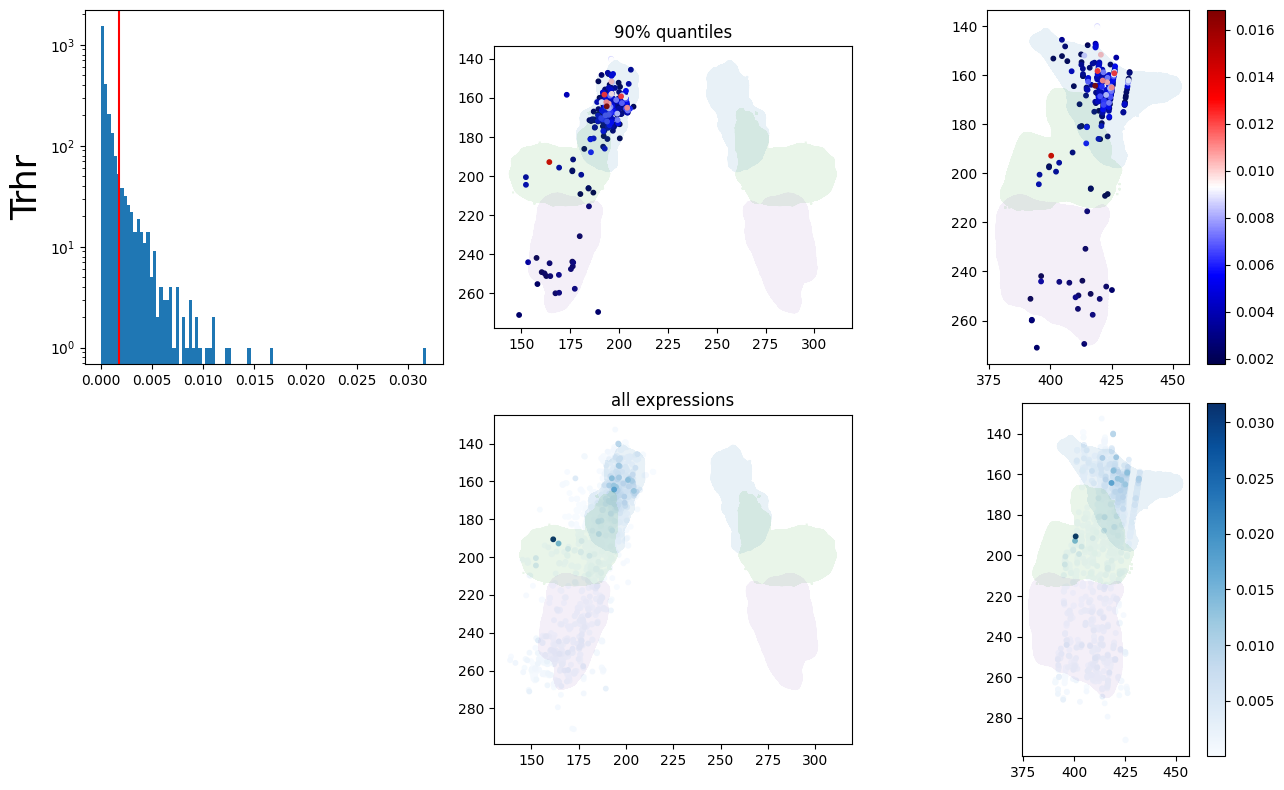

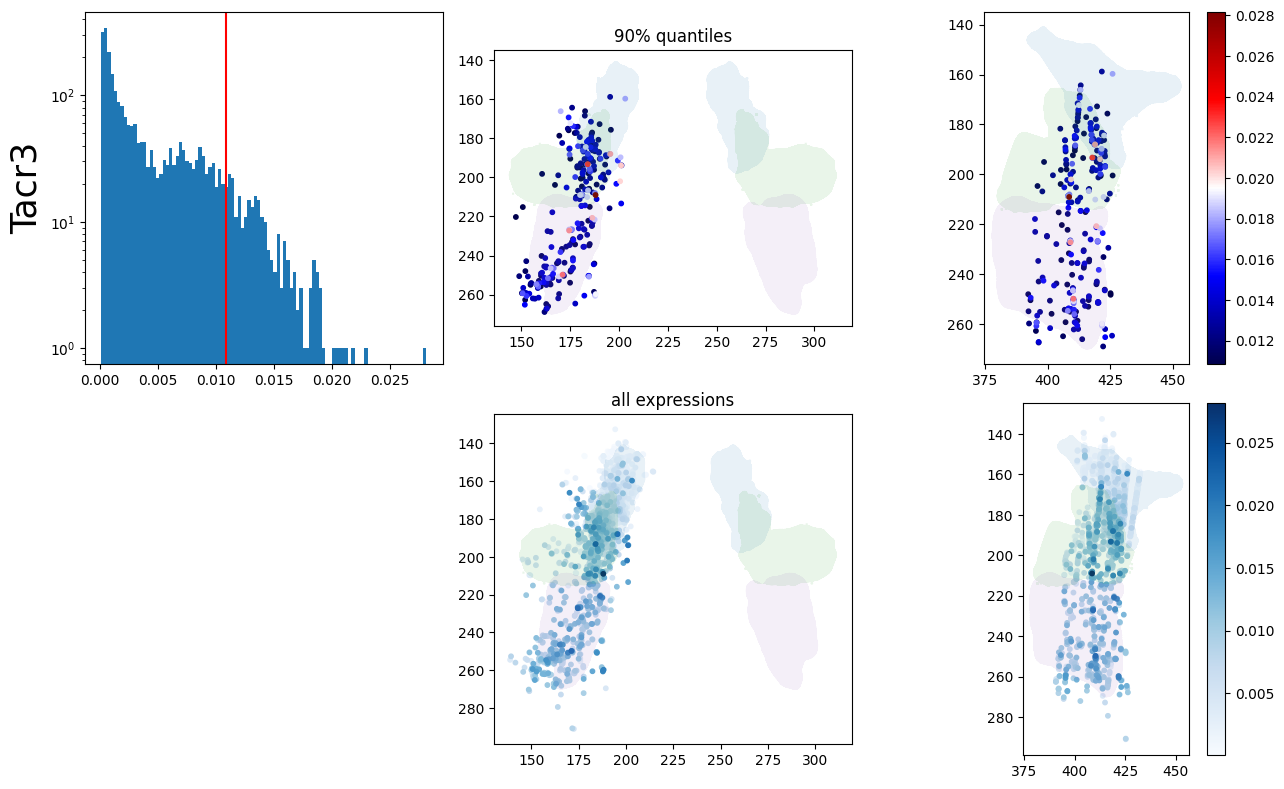

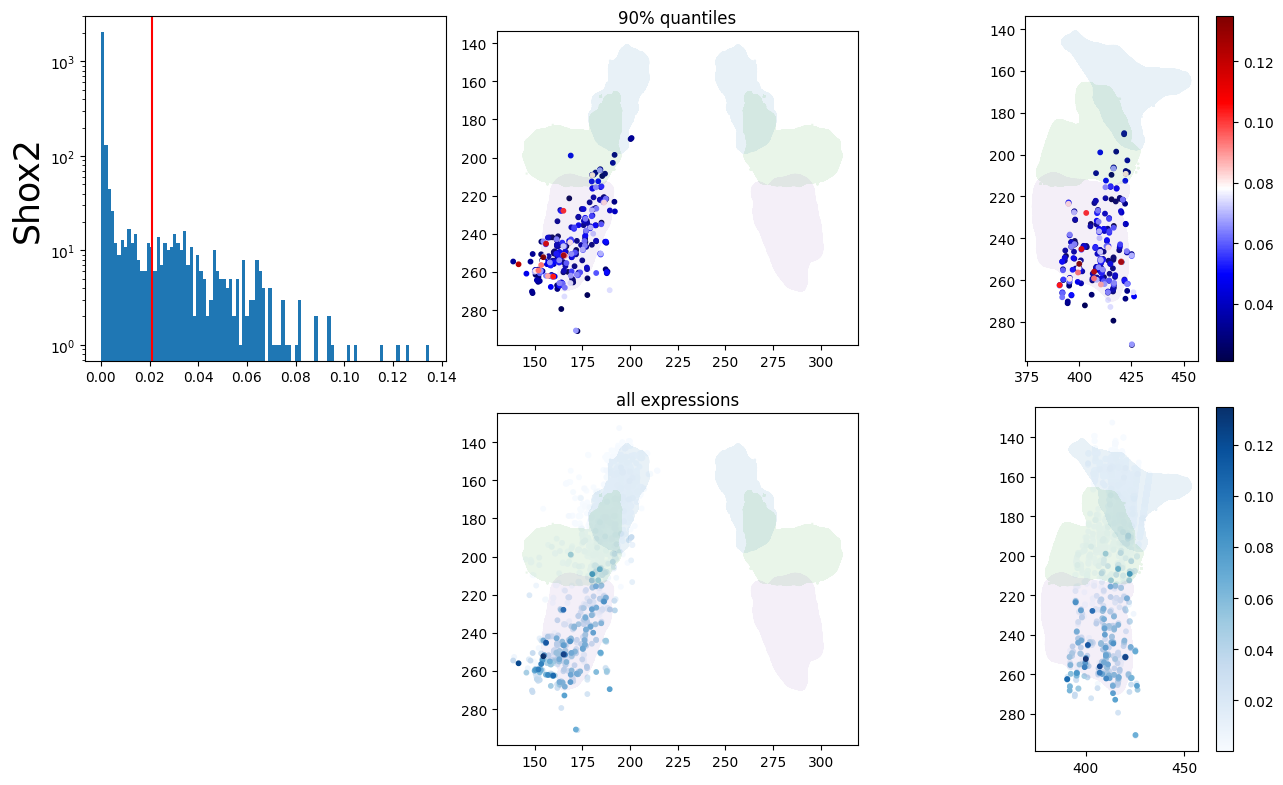

In [165]:
quantile_thre = 0.9
for top_gene in intersted_genes:
    gene_index = list(adata_mer.var_names).index(top_gene)
    gene_expression = adata_mer.X[:, gene_index].toarray().flatten() if hasattr(adata_mer.X, "toarray") else adata_mer.X[:, gene_index]
    ordered = np.argsort(gene_expression)
    xy_target = adata_mer.obsm['spatial'][ordered]
    gene_expression=gene_expression[ordered]
    gene_expression_all = gene_expression.copy()
    xy_target_all = xy_target.copy()

    thre = np.quantile(gene_expression_all,quantile_thre )
    if top_gene != 'Trhr':
        xy_target = xy_target[(gene_expression>thre) ]
        gene_expression=gene_expression[(gene_expression>thre)]
    else:
        xy_target = xy_target[(gene_expression>thre) & (gene_expression<0.03)]
        gene_expression=gene_expression[(gene_expression>thre) & (gene_expression<0.03)]

    cmap = 'seismic'
    fig, axes = plt.subplots(2,3,figsize = (13,8))        
    ax = axes[0,0]
    ax.hist(gene_expression_all,bins = 100);
    ax.set_yscale('log');ax.set_ylabel(top_gene, fontsize = 25)
    ax.axvline(thre, color='red')
    
    ax = axes[0,1]
    ax.scatter(xy_target[:,2],xy_target[:,1], c= gene_expression,cmap = cmap,s= 10)
    ax.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    ax.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    ax.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
    ax.invert_yaxis();ax.set_aspect('equal')
    ax.set_title(f'{int(quantile_thre*100)}% quantiles')

    ax = axes[0,2]
    pltcbar = ax.scatter(xy_target[:,0],xy_target[:,1], c= gene_expression,cmap = cmap,s=10)
    ax.triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    ax.triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    ax.triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
    ax.invert_yaxis();ax.set_aspect('equal')
    fig.colorbar(pltcbar)

    axes[1,0].axis('off')
    cmap = 'Blues'
    ax = axes[1,1]
    ax.scatter(xy_target_all[:,2],xy_target_all[:,1], c= gene_expression_all,cmap = cmap,s= 10)
    ax.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    ax.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    ax.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
    ax.invert_yaxis();ax.set_aspect('equal')
    ax.set_title('all expressions')

    ax = axes[1,2]
    pltcbar = ax.scatter(xy_target_all[:,0],xy_target_all[:,1], c= gene_expression_all,cmap = cmap,s=10)
    ax.triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    ax.triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    ax.triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
    ax.invert_yaxis();ax.set_aspect('equal')
    fig.colorbar(pltcbar)
    fig.tight_layout()